## 0. 共通準備（毎回実行）

In [ ]:
# Google Drive をマウント
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 参照フォルダ
base_path = "/content/drive/MyDrive/Kaggle研究会/playground-series-s6e4"

train = pd.read_csv(f"{base_path}/train.csv")
test = pd.read_csv(f"{base_path}/test.csv")
sample_sub = pd.read_csv(f"{base_path}/sample_submission.csv")

Mounted at /content/drive


In [ ]:
target = "Irrigation_Need"

jp_labels = {
    "id": "ID（識別番号）",
    "Soil_Type": "土壌の種類",
    "Soil_pH": "土壌のpH（酸性度）",
    "Soil_Moisture": "土壌水分量",
    "Organic_Carbon": "有機炭素含有量",
    "Electrical_Conductivity": "電気伝導度（塩分濃度）",
    "Temperature_C": "気温（摂氏）",
    "Humidity": "湿度",
    "Rainfall_mm": "降水量（mm）",
    "Sunlight_Hours": "日照時間",
    "Wind_Speed_kmh": "風速（km/h）",
    "Crop_Type": "作物の種類",
    "Crop_Growth_Stage": "作物の生育ステージ",
    "Season": "季節",
    "Irrigation_Type": "灌漑（水やり）の種類",
    "Water_Source": "水源",
    "Field_Area_hectare": "圃場（畑）の面積（ヘクタール）",
    "Mulching_Used": "マルチングの使用有無",
    "Previous_Irrigation_mm": "前回の灌漑量（mm）",
    "Region": "地域",
    "Irrigation_Need": "灌漑の必要性",
}

def jp(col):
    return jp_labels.get(col, col)

def jp_with_en(col):
    return f"{jp(col)}（{col}）"

feature_cols = [c for c in train.columns if c in test.columns and c != "id"]

num_cols = train[feature_cols].select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in feature_cols if c not in num_cols]

print("target:", target)
print("feature_cols:", len(feature_cols))
print("num_cols:", len(num_cols))
print("cat_cols:", len(cat_cols))

target: Irrigation_Need
feature_cols: 19
num_cols: 11
cat_cols: 8


## 1. 目的と評価指標の整理（Kaggleサイトより）

* 目的：testデータの各idについて、灌漑必要性（Irrigation_Need）を Low / Medium / High の3クラスで予測する

* タスク：多クラス分類
  * カテゴリラベルを予測する
  * 予測値は Low / Medium / High のいずれか

* 評価指標：Balanced Accuracy
  * 各クラス（Low / Medium / High）の正解率をバランスよく評価する指標
  * クラス数に偏りがある場合でも、少数クラスの予測性能が評価に反映される

* 提出形式：id, Irrigation_Need
  * testデータのIDごとに、予測したクラスラベル（Low / Medium / High）を提出する

* 注意：データは実データではなく、合成データ（synthetic data）

## 2. データ定義

In [ ]:
# 基本情報
print("train:", train.shape)
print("test:", test.shape)
print("sample_submission:", sample_sub.shape)

# 目的変数・特徴量
print("目的変数:", target, "→", jp(target))
print("特徴量数:", len(feature_cols))
print("数値特徴量:", len(num_cols), num_cols)
print("カテゴリ特徴量:", len(cat_cols), cat_cols)

# 中身確認
display(train.head())
display(test.head())
display(sample_sub.head())

# 日本語DataFrame（確認用）
train_jp = train.rename(columns=jp_labels)
test_jp  = test.rename(columns=jp_labels)

display(train_jp.head())

train: (630000, 21)
test: (270000, 20)
sample_submission: (270000, 2)
目的変数: Irrigation_Need → 灌漑の必要性
特徴量数: 19
数値特徴量: 11 ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
カテゴリ特徴量: 8 ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,630000,Silt,6.36,26.19,0.59,2.81,17.83,30.24,1533.38,5.40,3.00,Maize,Sowing,Rabi,Canal,River,13.59,Yes,47.48,West
1,630001,Clay,5.87,9.88,1.18,3.26,21.18,78.07,576.05,7.22,15.88,Cotton,Sowing,Rabi,Drip,Reservoir,6.12,Yes,56.43,South
2,630002,Sandy,6.22,26.55,0.96,0.85,26.87,60.35,545.30,9.43,2.63,Wheat,Sowing,Kharif,Sprinkler,Reservoir,3.11,Yes,20.00,East
3,630003,Clay,7.68,53.58,0.83,0.55,41.74,36.05,1211.03,6.69,1.86,Maize,Harvest,Rabi,Canal,Groundwater,2.27,No,102.99,North
4,630004,Loamy,5.23,59.02,0.54,2.11,41.08,52.47,1321.91,4.11,5.71,Cotton,Sowing,Kharif,Canal,Groundwater,12.39,Yes,13.33,Central


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


,ID（識別番号）,土壌の種類,土壌のpH（酸性度）,土壌水分量,有機炭素含有量,電気伝導度（塩分濃度）,気温（摂氏）,湿度,降水量（mm）,日照時間,...,作物の種類,作物の生育ステージ,季節,灌漑（水やり）の種類,水源,圃場（畑）の面積（ヘクタール）,マルチングの使用有無,前回の灌漑量（mm）,地域,灌漑の必要性
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


確認結果
*   trainは学習用データ（正解あり）、testは予測対象データ（正解なし）、sample_submissionは提出形式確認用データである
*   目的変数は Irrigation_Need（灌漑の必要性）であり、Low / Medium / High の3クラスを予測する多クラス分類問題である
*   1行は1つの農地（圃場）の状態を表しており、土壌・気象・作物・灌漑条件などの特徴量から、灌漑（水やり）の必要レベルを予測するデータである
*   特徴量は19列で構成されており、数値特徴量11列、カテゴリ特徴量8列に分かれる。
*   数値特徴量には、土壌水分量・降水量・気温・湿度などの環境データが含まれ、
カテゴリ特徴量には、作物種類・生育ステージ・灌漑方法・地域などの条件データが含まれる
*   idは識別子であり、モデル学習には使用しない

## 3. データ粒度確認

In [ ]:
# ■ 3-1) id の一意性確認
print("■ idの一意性")

if "id" in train.columns and "id" in test.columns:
    print("train id unique:", train["id"].is_unique)
    print("test  id unique:", test["id"].is_unique)

# ■ 3-2) 重複行確認
print("\n■ 重複行確認")

print("train duplicated rows:", train.duplicated().sum())
print("test  duplicated rows:", test.duplicated().sum())

# ■ 3-3) id重複確認
print("\n■ id重複確認")

dup_id = train["id"].duplicated().sum()
print("train duplicated id:", dup_id)

if dup_id > 0:
    display(
        train[
            train["id"].duplicated(keep=False)
        ].sort_values("id").head(10)
    )

# ■ 3-4) 目的変数確認
print("\n■ 目的変数確認")

print("target:", target)
print("dtype :", train[target].dtype)

print("\nクラス数:", train[target].nunique())

print("\nクラス分布")
display(
    train[target]
    .value_counts(dropna=False)
    .to_frame("count")
)

■ idの一意性
train id unique: True
test  id unique: True

■ 重複行確認
train duplicated rows: 0
test  duplicated rows: 0

■ id重複確認
train duplicated id: 0

■ 目的変数確認
target: Irrigation_Need
dtype : object

クラス数: 3

クラス分布


,count
Irrigation_Need,
Low,369917
Medium,239074
High,21009


確認結果

*   1行の単位：id が一意  
*   重複：重複行・id重複はない  
*   目的変数：Irrigation_Need は文字カテゴリ（Low / Medium / High）  
*   クラス数：3クラスの多クラス分類  
*   欠損：目的変数の欠損はない  
*   分布：Low が最多（369,917件）、High が最少（21,009件）でクラス不均衡がある  
*   学習・評価：行単位で Irrigation_Need を予測する多クラス分類問題

## 4. 欠損・型確認

In [ ]:
all_cols = feature_cols + [target]

# 4-1) 欠損率・型・ユニーク数を一覧化
summary = pd.DataFrame({
    "列名": all_cols,
    "日本語訳": [jp(c) for c in all_cols],
    "役割": ["説明変数"] * len(feature_cols) + ["目的変数"],
    "dtype": [train[c].dtype for c in all_cols],
    "欠損数_train": [train[c].isna().sum() for c in all_cols],
    "欠損率_train_%": [(train[c].isna().mean() * 100).round(2) for c in all_cols],
    "欠損数_test": [test[c].isna().sum() if c in test.columns else None for c in all_cols],
    "欠損率_test_%": [(test[c].isna().mean() * 100).round(2) if c in test.columns else None for c in all_cols],
    "ユニーク数_train": [train[c].nunique(dropna=True) for c in all_cols],
})

display(summary.sort_values(["役割", "列名"]))

# 4-2) 数値列・カテゴリ列の確認
print("数値列:", len(num_cols), num_cols)
print("カテゴリ列:", len(cat_cols), cat_cols)

# 4-3) train/testでカテゴリの種類がズレていないか確認
for c in cat_cols:
    train_set = set(train[c].dropna().unique())
    test_set = set(test[c].dropna().unique())

    only_train = train_set - test_set
    only_test = test_set - train_set

    print(f"\n[カテゴリ差分確認] {c}: {jp(c)}")
    print("trainにだけある値:", only_train if len(only_train) > 0 else "なし")
    print("testにだけある値:", only_test if len(only_test) > 0 else "なし")

,列名,日本語訳,役割,dtype,欠損数_train,欠損率_train_%,欠損数_test,欠損率_test_%,ユニーク数_train
19,Irrigation_Need,灌漑の必要性,目的変数,object,0,0.0,NaN,NaN,3
11,Crop_Growth_Stage,作物の生育ステージ,説明変数,object,0,0.0,0.0,0.0,4
10,Crop_Type,作物の種類,説明変数,object,0,0.0,0.0,0.0,6
4,Electrical_Conductivity,電気伝導度（塩分濃度）,説明変数,float64,0,0.0,0.0,0.0,341
15,Field_Area_hectare,圃場（畑）の面積（ヘクタール）,説明変数,float64,0,0.0,0.0,0.0,1466
6,Humidity,湿度,説明変数,float64,0,0.0,0.0,0.0,6475
13,Irrigation_Type,灌漑（水やり）の種類,説明変数,object,0,0.0,0.0,0.0,4
16,Mulching_Used,マルチングの使用有無,説明変数,object,0,0.0,0.0,0.0,2
3,Organic_Carbon,有機炭素含有量,説明変数,float64,0,0.0,0.0,0.0,131
17,Previous_Irrigation_mm,前回の灌漑量（mm）,説明変数,float64,0,0.0,0.0,0.0,10110


数値列: 11 ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
カテゴリ列: 8 ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

[カテゴリ差分確認] Soil_Type: 土壌の種類
trainにだけある値: なし
testにだけある値: なし

[カテゴリ差分確認] Crop_Type: 作物の種類
trainにだけある値: なし
testにだけある値: なし

[カテゴリ差分確認] Crop_Growth_Stage: 作物の生育ステージ
trainにだけある値: なし
testにだけある値: なし

[カテゴリ差分確認] Season: 季節
trainにだけある値: なし
testにだけある値: なし

[カテゴリ差分確認] Irrigation_Type: 灌漑（水やり）の種類
trainにだけある値: なし
testにだけある値: なし

[カテゴリ差分確認] Water_Source: 水源
trainにだけある値: なし
testにだけある値: なし

[カテゴリ差分確認] Mulching_Used: マルチングの使用有無
trainにだけある値: なし
testにだけある値: なし

[カテゴリ差分確認] Region: 地域
trainにだけある値: なし
testにだけある値: なし


確認結果
*   欠損：train / test ともに欠損はない（欠損率0.0%）  
*   型：説明変数は数値列11列、カテゴリ列8列で構成される  
*   目的変数：Irrigation_Need は object型のカテゴリ変数（Low / Medium / High）  
*   カテゴリ差分：train / test 間で片方にしか存在しないカテゴリは確認されなかった  
*   ユニーク数：数値列はユニーク数が多く連続値として扱え、カテゴリ列は少数カテゴリで構成されている  
*   異常：欠損・型・カテゴリ差分の観点で大きな品質問題は見られない



## 5. データ可視化
*   5-1 目的変数の分布確認
*   5-2-1 数値特徴量の分布一覧
*   5-2-2 カテゴリ特徴量の割合一覧
*   5-3-1 目的変数別平均（数値特徴量）
*   5-3-2 カテゴリ × target
*   5-3-3 上位特徴量分布（数値特徴量のみ）
*   5-4 相関確認
*   5-5 train/test比較

In [ ]:
# 共通
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import pandas as pd
import math

sns.set_theme(style="whitegrid", context="notebook")

try:
    import japanize_matplotlib
except ImportError:
    !pip -q install japanize-matplotlib
    import japanize_matplotlib

# 日本語フォント設定
plt.rcParams["font.family"] = "IPAexGothic"
plt.rcParams["axes.unicode_minus"] = False

# 表示順
class_order = ["Low", "Medium", "High"]

# 日本語ラベル
label_map = {
    "Low": "低い",
    "Medium": "中程度",
    "High": "高い"
}

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 40.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


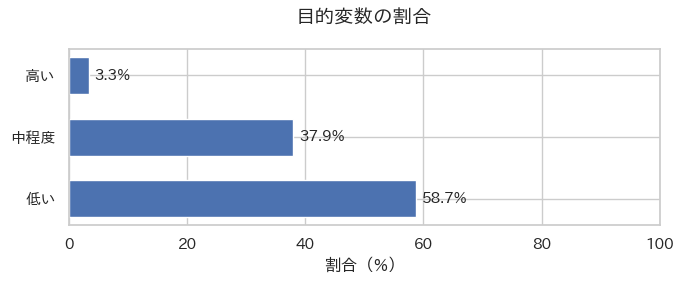

In [ ]:
# 5-1) 目的変数の分布確認

vc_ratio = train[target].value_counts(normalize=True).reindex(class_order) * 100
vc_ratio_jp = vc_ratio.copy()
vc_ratio_jp.index = vc_ratio_jp.index.map(label_map)

fig, ax = plt.subplots(figsize=(7, 3))

bars = ax.barh(
    vc_ratio_jp.index,
    vc_ratio_jp.values,
    height=0.6
)

ax.set_title("目的変数の割合", fontsize=14, pad=18)
ax.set_xlabel("割合（%）")
ax.set_xlim(0, 100)

for bar in bars:
    ratio = bar.get_width()

    ax.text(
        ratio + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{ratio:.1f}%",
        va="center",
        ha="left",
        fontsize=11
    )

plt.tight_layout()
plt.show()

5-1) 目的変数の分布確認

確認結果

*   Lowが約58.7%で最も多く、Mediumが約37.9%、Highは約3.3%と少ない
*   クラス不均衡が存在し、特に High は少数クラスである
*   評価指標として Balanced Accuracy を採用する
*   class_weight による不均衡対応を検討する

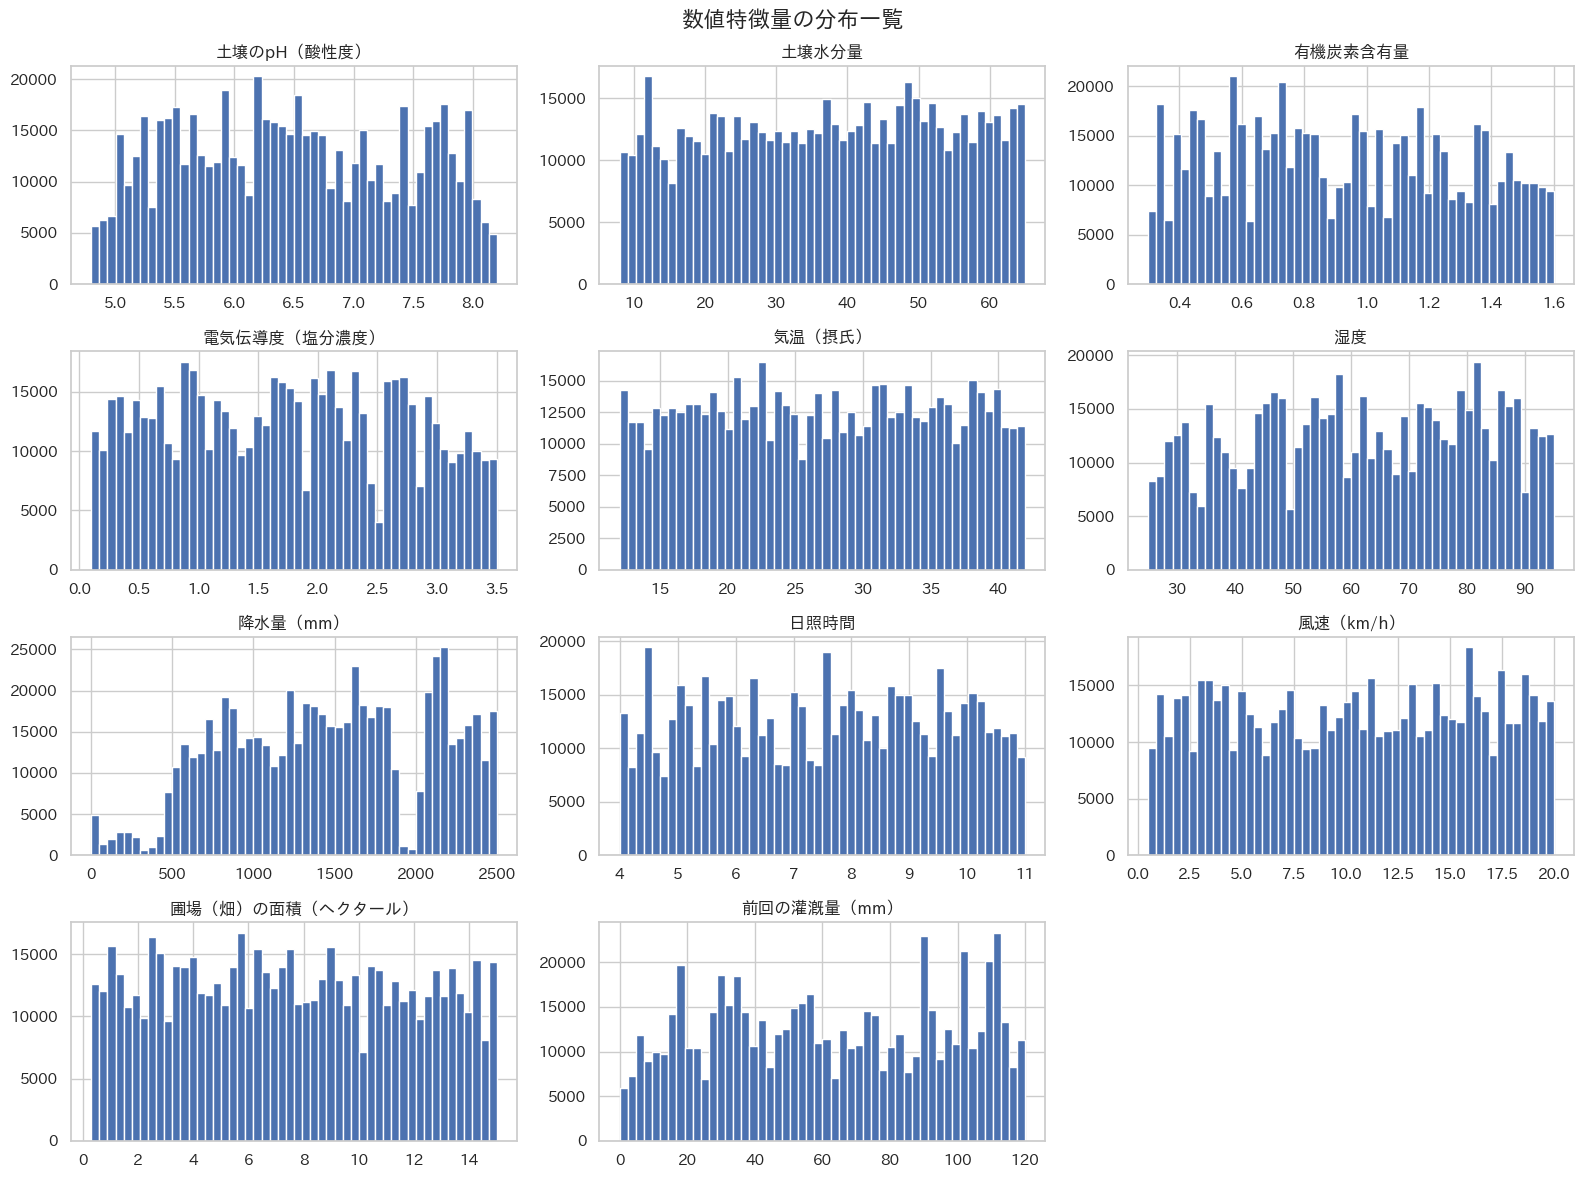

In [ ]:
# 5-2-1) 数値特徴量の分布一覧

train_jp = train.rename(columns=jp_labels)

num_cols_jp = [jp(c) for c in num_cols]

train_jp[num_cols_jp].hist(
    bins=50,
    figsize=(16, 12),
    layout=(int(np.ceil(len(num_cols_jp) / 3)), 3)
)

plt.suptitle("数値特徴量の分布一覧", fontsize=16)

plt.tight_layout()
plt.show()

5-2-1) 数値特徴量の分布一覧（「値の分布」を見る）
*   見ているもの：値がどの範囲にどれくらい存在するか
*   グラフ：ヒストグラム
*   確認ポイント：
    *   分布形状
    *   偏り
    *   外れ値
    *   値の範囲
    *   スケール差
    *   一部に集中していないか
*   今回の例：
    *   降水量 → 範囲が広い
    *   pH → 狭い範囲
    *   湿度 → 比較的均等

確認結果
*   極端な外れ値や異常値は大きく見られない
*   土壌水分量、気温、湿度、風速などは比較的なだらかな分布
*   降水量は一部で偏りが見られる
*   特徴量ごとにスケール差は存在する（値の単位や範囲がバラバラ）
*   LightGBM を使用するためスケーリングは行わない
*   追加の外れ値除去や欠損補完は不要と判断した

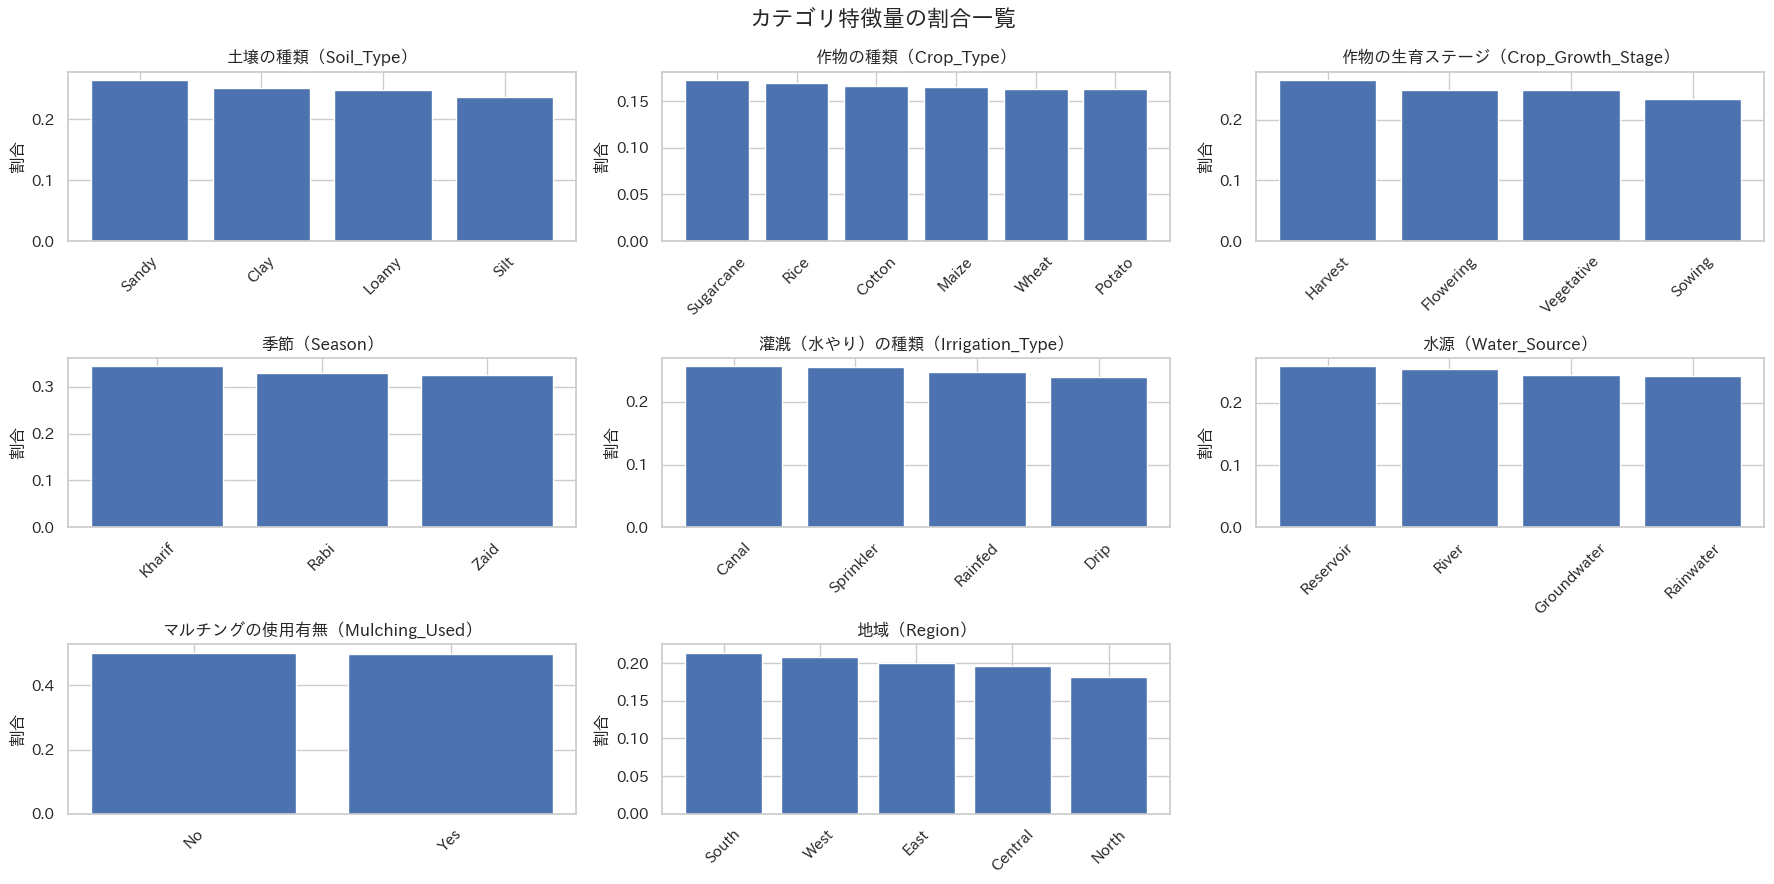

In [ ]:
# 5-2-2) カテゴリ特徴量の割合一覧

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, n_rows * 3)
)

axes = axes.flatten()

for i, col in enumerate(cat_cols):

    vc = train[col].value_counts(normalize=True)

    axes[i].bar(
        vc.index.astype(str),
        vc.values
    )

    axes[i].set_title(f"{jp(col)}（{col}）")
    axes[i].set_ylabel("割合")
    axes[i].tick_params(axis="x", rotation=45)

# 余ったsubplot削除
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("カテゴリ特徴量の割合一覧", fontsize=16)

plt.tight_layout()
plt.show()

5-2-2) カテゴリ特徴量の割合一覧（「カテゴリの割合」を見る）
*   見ているもの：各カテゴリがどれくらい存在するか
*   グラフ：棒グラフ（割合）
*   確認ポイント：
    *   カテゴリの偏り
    *   少数カテゴリ
    *   極端に多いカテゴリ
    *   train/testでズレてないか

    ⇒特定カテゴリだけ極端に多くないか

確認結果
*   各カテゴリ特徴量は比較的均等に分布しており、極端に少ないカテゴリは大きく見られない
*   土壌種類、作物種類、灌漑方法、地域などに大きな偏りはなく、マルチング使用有無（Yes / No）もほぼ同程度である
*   カテゴリ特徴量はそのまま学習に利用可能と判断した

,土壌のpH（酸性度）（Soil_pH）,土壌水分量（Soil_Moisture）,有機炭素含有量（Organic_Carbon）,電気伝導度（塩分濃度）（Electrical_Conductivity）,気温（摂氏）（Temperature_C）,湿度（Humidity）,降水量（mm）（Rainfall_mm）,日照時間（Sunlight_Hours）,風速（km/h）（Wind_Speed_kmh）,圃場（畑）の面積（ヘクタール）（Field_Area_hectare）,前回の灌漑量（mm）（Previous_Irrigation_mm）
Irrigation_Need,,,,,,,,,,,
Low,6.487805,43.305902,0.920680,1.731755,25.347708,61.949194,1500.534313,7.511125,9.216424,7.447241,61.718330
Medium,6.465867,29.743961,0.926116,1.769208,28.886683,61.004887,1444.475028,7.521290,11.793668,7.625725,63.181715
High,6.578282,17.669875,0.924143,1.690880,34.568134,61.119576,989.156678,7.463138,14.642639,7.530391,63.053300


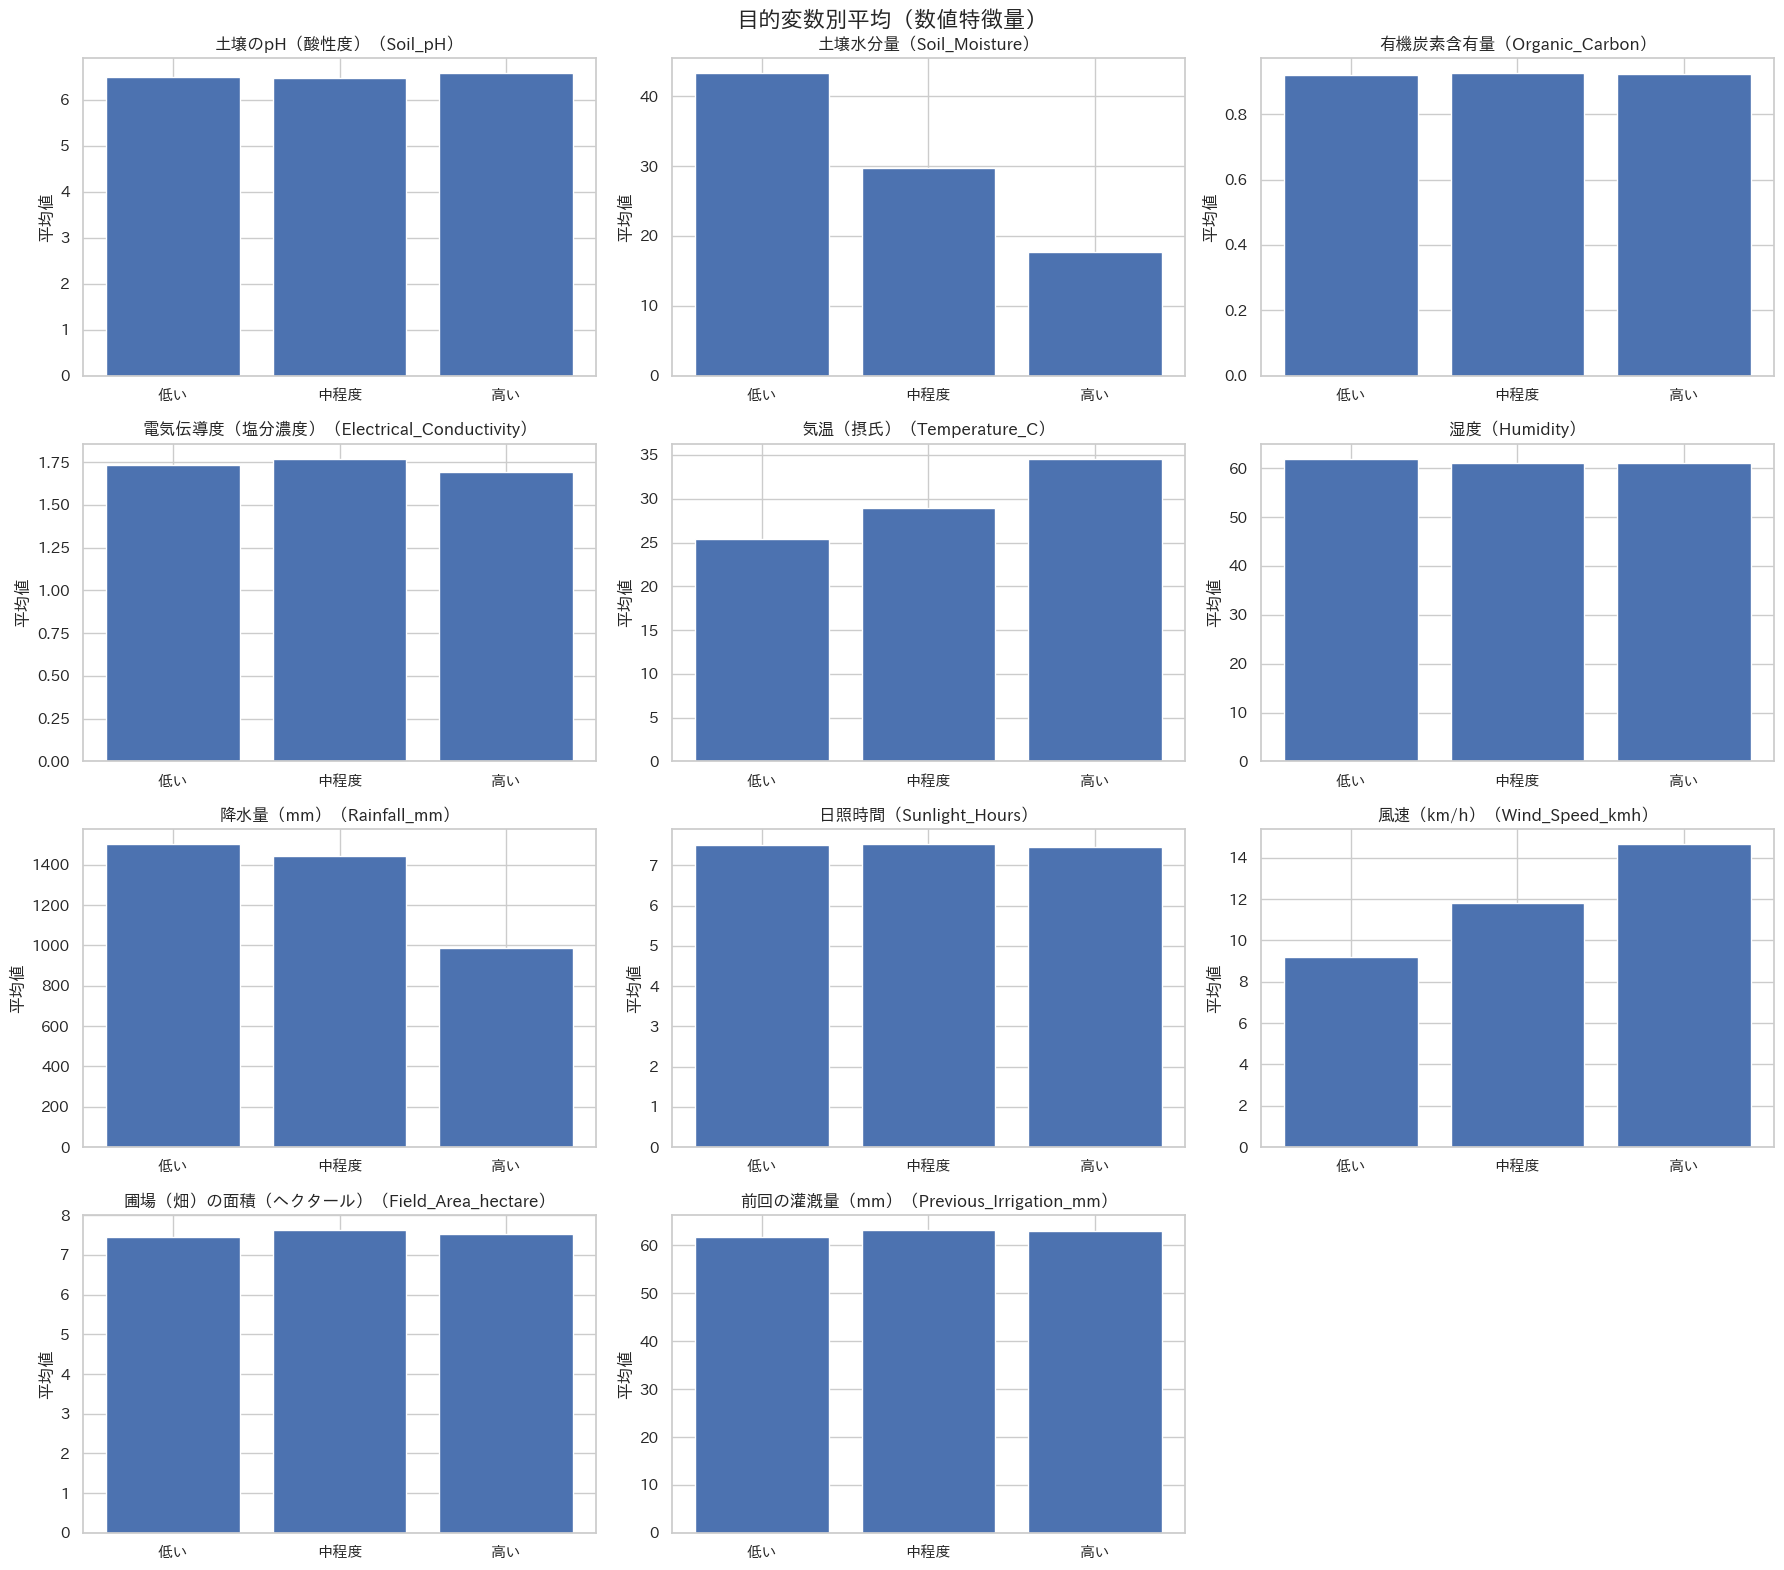

In [ ]:
# 5-3-1) 目的変数別平均（数値特徴量）

# 表用：Low → Medium → High
table_order = ["Low", "Medium", "High"]

target_mean = (
    train
    .groupby(target)[num_cols]
    .mean()
    .reindex(table_order)
)

target_mean_jp = target_mean.copy()

target_mean_jp.columns = [
    jp_with_en(c)
    for c in target_mean_jp.columns
]

display(target_mean_jp)


# グラフ表示（目的変数別平均）

import math

# グラフ用：左から Low → Medium → High
class_order = ["Low", "Medium", "High"]

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, n_rows * 4)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):

    mean_values = (
        train
        .groupby(target)[col]
        .mean()
        .reindex(class_order)
    )

    axes[i].bar(
        [label_map[c] for c in class_order],
        mean_values.values
    )

    axes[i].set_title(f"{jp(col)}（{col}）")
    axes[i].set_ylabel("平均値")

# 余ったsubplot削除
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("目的変数別平均（数値特徴量）", fontsize=16)

plt.tight_layout()
plt.show()

5-3-1) 目的変数別平均（数値特徴量）
*   目的：数値特徴量ごとにHigh / Medium / Low で平均値が違うか確認する
*   見ていること：
    *   どの特徴量でクラス差が大きいか
    *   灌漑必要性と関係がありそうか
*   役割：数値特徴量の「傾向差」を把握する

確認結果
*   目的変数別の平均を見ると、High は土壌水分量・降水量が低く、気温・風速が高い傾向がある
*   一方、Low は土壌水分量・降水量が高く、気温・風速が低い
*   このことから、乾燥・高温・風が強い条件ほど、灌漑必要性が高くなる傾向が見られる


土壌の種類（Soil_Type）


Irrigation_Need,High,Medium,Low
Soil_Type,,,
Clay,0.264,0.251,0.251
Loamy,0.215,0.243,0.253
Sandy,0.306,0.268,0.259
Silt,0.214,0.238,0.236


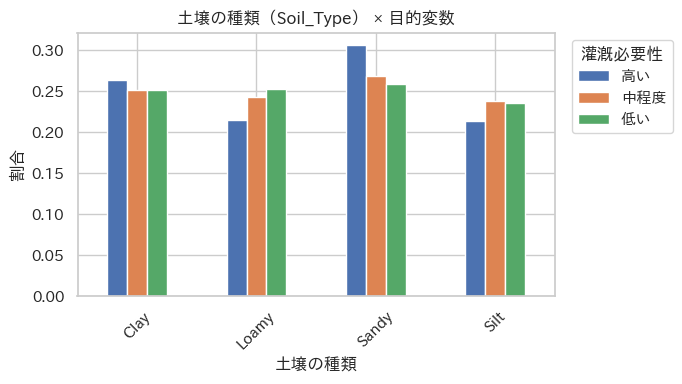


作物の種類（Crop_Type）


Irrigation_Need,High,Medium,Low
Crop_Type,,,
Cotton,0.180,0.165,0.166
Maize,0.209,0.169,0.161
Potato,0.134,0.170,0.160
Rice,0.119,0.168,0.173
Sugarcane,0.203,0.168,0.175
Wheat,0.155,0.160,0.166


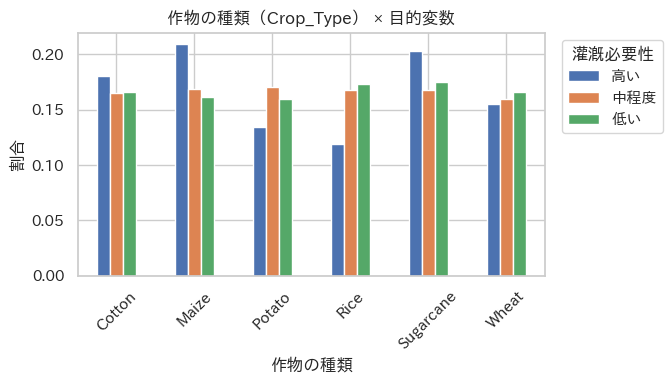


作物の生育ステージ（Crop_Growth_Stage）


Irrigation_Need,High,Medium,Low
Crop_Growth_Stage,,,
Flowering,0.483,0.415,0.130
Harvest,0.026,0.104,0.384
Sowing,0.011,0.078,0.348
Vegetative,0.480,0.403,0.138


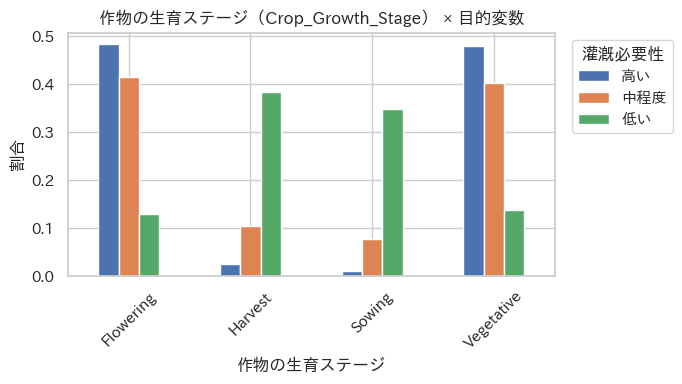


季節（Season）


Irrigation_Need,High,Medium,Low
Season,,,
Kharif,0.359,0.357,0.334
Rabi,0.318,0.320,0.337
Zaid,0.323,0.323,0.328


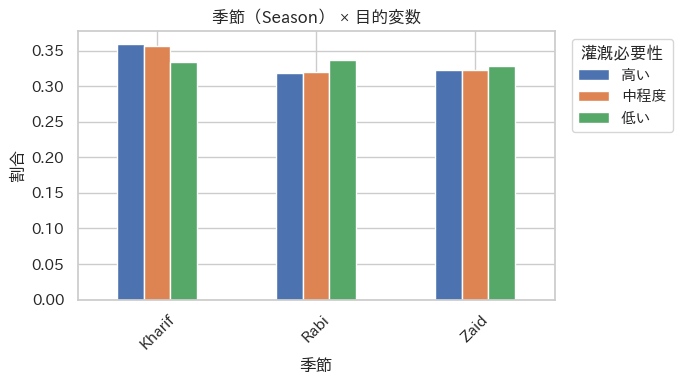


灌漑（水やり）の種類（Irrigation_Type）


Irrigation_Need,High,Medium,Low
Irrigation_Type,,,
Canal,0.294,0.274,0.244
Drip,0.192,0.239,0.243
Rainfed,0.246,0.234,0.255
Sprinkler,0.268,0.253,0.258


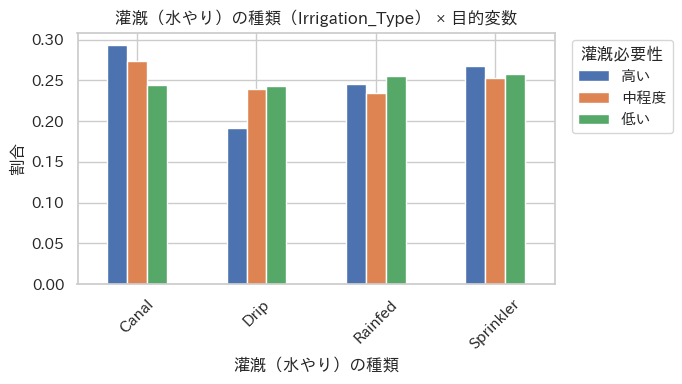


水源（Water_Source）


Irrigation_Need,High,Medium,Low
Water_Source,,,
Groundwater,0.172,0.242,0.250
Rainwater,0.244,0.232,0.250
Reservoir,0.253,0.276,0.248
River,0.330,0.250,0.252


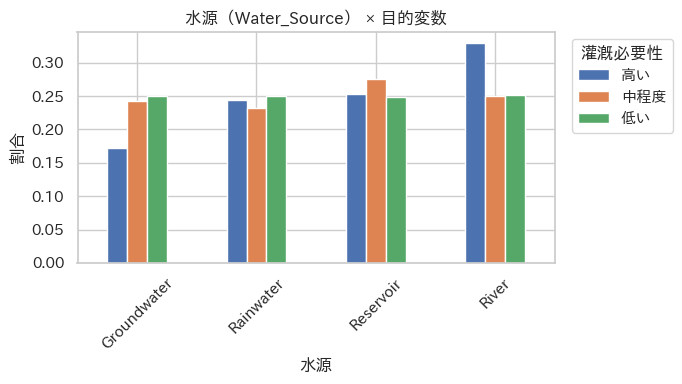


マルチングの使用有無（Mulching_Used）


Irrigation_Need,High,Medium,Low
Mulching_Used,,,
No,0.882,0.657,0.381
Yes,0.118,0.343,0.619


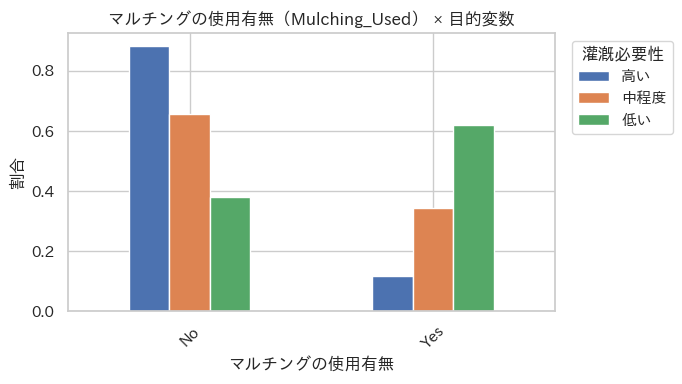


地域（Region）


Irrigation_Need,High,Medium,Low
Region,,,
Central,0.202,0.193,0.198
East,0.172,0.199,0.202
North,0.186,0.186,0.178
South,0.223,0.214,0.214
West,0.216,0.208,0.208


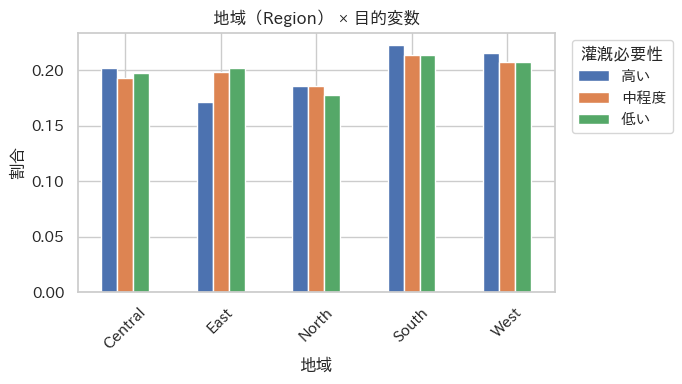

In [ ]:
# 5-3-2) カテゴリ × target

for col in cat_cols:

    print(f"\n{jp(col)}（{col}）")

    # クロス集計（割合）
    ctab = pd.crosstab(
        train[col],
        train[target],
        normalize="columns"
    ).round(3)

    # 列順を固定
    ctab = ctab[["High", "Medium", "Low"]]

    display(ctab)

    # グラフ表示
    ctab_plot = ctab.copy()

    # 列名を日本語化
    ctab_plot.columns = [
        label_map.get(c, c)
        for c in ctab_plot.columns
    ]

    ax = ctab_plot.plot(
        kind="bar",
        figsize=(7, 4)
    )

    ax.set_title(f"{jp(col)}（{col}） × 目的変数")
    ax.set_xlabel(jp(col))
    ax.set_ylabel("割合")

    plt.xticks(rotation=45)

    # 凡例
    ax.legend(
        title="灌漑必要性",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

5-3-2) カテゴリ × target
*   目的：カテゴリごとのHigh / Medium / Low の割合差を確認する
*   見ていること：
    *   どのカテゴリで High が多いか
    *   どのカテゴリで Low が多いか
    *   クラス偏りがあるか
*   役割：カテゴリ特徴量と目的変数の関係を確認する

確認結果

*   作物の生育ステージはクラス差が非常に大きく、Flowering・Vegetativeでは High が多く、Harvest・Sowingでは Low が多い傾向が見られる
*   マルチングの使用有無も差が大きく、No は High の割合が非常に高く、Yes は Low の割合が高い
*   水源では River が High にやや多く、Groundwater は High が少ない傾向が見られる
*   土壌の種類では Sandy が High にやや多く、Loamy・Silt は Low / Medium が比較的多い
*   灌漑（水やり）の種類では Canal・Sprinkler が High にやや多く、Drip は Low が多い傾向が見られる
*   作物の種類では Maize・Sugarcane が High にやや多く、Rice・Potato は Low が多い傾向が見られる
*   季節と地域はクラス間の割合差が小さく、単体での影響は比較的小さいと考えられる

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041040 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2709
[LightGBM] [Info] Number of data points in the train set: 630000, number of used features: 19
[LightGBM] [Info] Start training from score -3.400769
[LightGBM] [Info] Start training from score -0.532441
[LightGBM] [Info] Start training from score -0.968947


,feature,日本語訳,importance
7,Rainfall_mm,降水量（mm）,1724
2,Soil_Moisture,土壌水分量,1221
5,Temperature_C,気温（摂氏）,1079
9,Wind_Speed_kmh,風速（km/h）,924
16,Mulching_Used,マルチングの使用有無,697
17,Previous_Irrigation_mm,前回の灌漑量（mm）,629
6,Humidity,湿度,583
11,Crop_Growth_Stage,作物の生育ステージ,361
1,Soil_pH,土壌のpH（酸性度）,345
8,Sunlight_Hours,日照時間,333


上位数値特徴量: ['Rainfall_mm', 'Soil_Moisture', 'Temperature_C', 'Wind_Speed_kmh', 'Previous_Irrigation_mm']


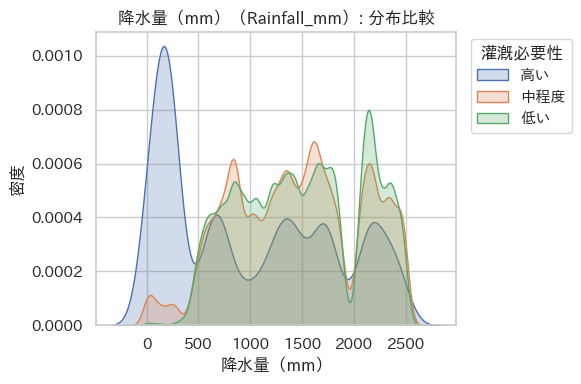

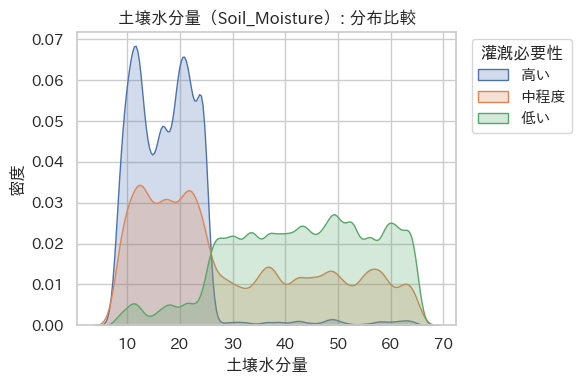

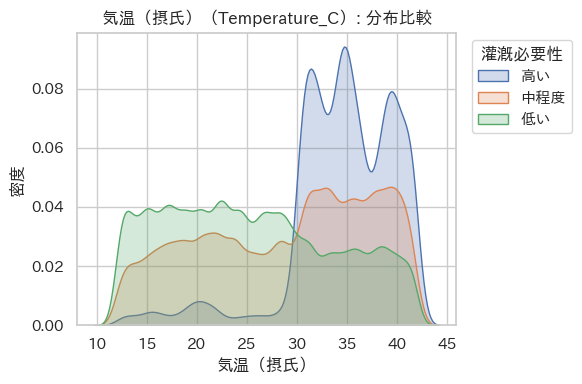

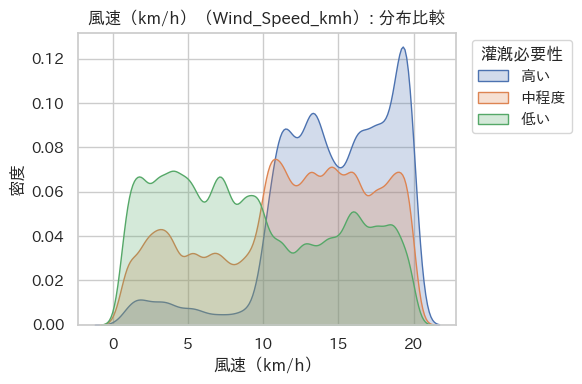

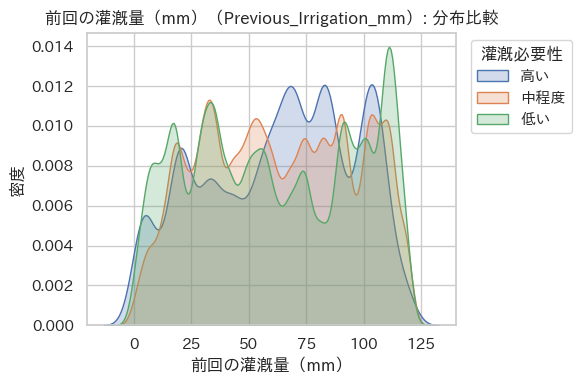

In [ ]:
# 5-3-3) 上位特徴量分布（数値特徴量のみ）

try:
    import lightgbm as lgb
except ImportError:
    !pip -q install lightgbm
    import lightgbm as lgb

from sklearn.preprocessing import LabelEncoder


# 仮モデル作成

X = train[feature_cols].copy()

# カテゴリ型変換
for col in cat_cols:
    X[col] = X[col].astype("category")

# 目的変数エンコード
le = LabelEncoder()

y_enc = le.fit_transform(train[target])

# 仮LightGBM
model_tmp = lgb.LGBMClassifier(
    objective="multiclass",
    random_state=42
)

model_tmp.fit(X, y_enc)


# 特徴量重要度

importance = pd.DataFrame({
    "feature": X.columns,
    "日本語訳": [jp(c) for c in X.columns],
    "importance": model_tmp.feature_importances_
}).sort_values("importance", ascending=False)

display(importance.head(10))


# 数値特徴量だけ抽出

top_num_cols = [
    c for c in importance["feature"]
    if c in num_cols
][:5]

print("上位数値特徴量:", top_num_cols)


# 分布比較

# 表示順
class_order_plot = ["High", "Medium", "Low"]

for col in top_num_cols:

    plt.figure(figsize=(6, 4))

    for cls in class_order_plot:

        mask = train[target].eq(cls)

        sns.kdeplot(
            train.loc[mask, col].dropna(),
            label=label_map[cls],
            fill=True,
            alpha=0.25
        )

    plt.title(f"{jp(col)}（{col}）: 分布比較")

    plt.xlabel(jp(col))
    plt.ylabel("密度")

    plt.legend(
        title="灌漑必要性",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

5-3-3) 上位特徴量分布
*   目的：LightGBM重要度で上位だった数値特徴量の分布差を詳しく確認する
*   流れ：
    1.   仮LightGBM feature_importances_で重要度確認
    2.   上位特徴量選定 top_num_cols
    3.   分布比較 KDE / histで、クラスごとの分布のズレを見る
*   見ていること：
    *   分布が分離しているか
    *   クラス差が大きいか
    *   モデルが使いやすそうか
*   役割：重要特徴量の「分布差」を詳しく確認する

確認結果
*   LightGBM重要度では、降水量、土壌水分量、気温、風速、前回の灌漑量が上位特徴量となった
*   降水量は、High が低降水量側に集中し、Low は高降水量側に分布しているため、灌漑必要性との関係が大きいと考えられる
*   土壌水分量は、High が低水分側、Low が高水分側に分布しており、クラス分離が明確に見られる
*   気温は、High が高温側、Low が低温側に分布しており、気温上昇によって灌漑必要性が高まる傾向が確認できる
*   風速は、High が高風速側、Low が低風速側に分布しており、風速増加による乾燥の影響が示唆される
*   前回の灌漑量はクラス間の分布差が比較的小さく、他特徴量より分離は弱い
*   全体として、降水量・土壌水分量・気温・風速はクラス分離が比較的明確であり、灌漑必要性の予測に重要な特徴量であると考えられる

■ 相関上位


,feature1_jp,feature2_jp,corr
14,土壌水分量,降水量（mm）,0.044473
12,土壌水分量,気温（摂氏）,-0.037891
46,降水量（mm）,風速（km/h）,-0.032776
16,土壌水分量,風速（km/h）,-0.027865
18,土壌水分量,前回の灌漑量（mm）,-0.023434
34,気温（摂氏）,湿度,-0.020448
44,湿度,前回の灌漑量（mm）,0.018669
22,有機炭素含有量,降水量（mm）,-0.017391
35,気温（摂氏）,降水量（mm）,-0.016767
13,土壌水分量,湿度,0.015403


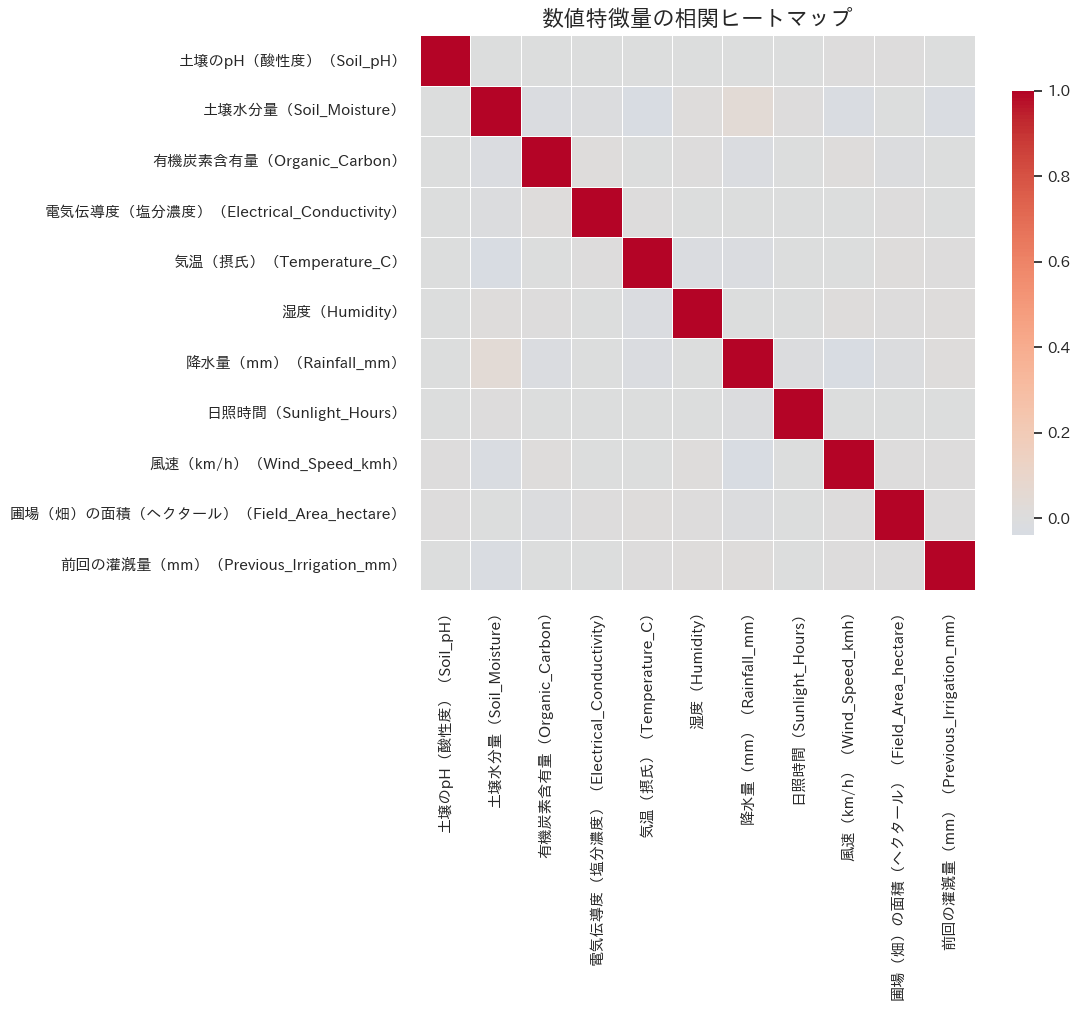

In [ ]:
# 5-4) 相関確認

# 相関行列

corr = train[num_cols].corr(numeric_only=True)

# 相関上位確認

corr_pairs = (
    corr.where(
        np.triu(
            np.ones(corr.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "feature1",
    "feature2",
    "corr"
]

# 絶対値順
corr_pairs["abs_corr"] = corr_pairs["corr"].abs()

corr_pairs = corr_pairs.sort_values(
    "abs_corr",
    ascending=False
)

# 日本語化
corr_pairs["feature1_jp"] = (
    corr_pairs["feature1"].map(jp)
)

corr_pairs["feature2_jp"] = (
    corr_pairs["feature2"].map(jp)
)

print("■ 相関上位")

display(
    corr_pairs[
        [
            "feature1_jp",
            "feature2_jp",
            "corr"
        ]
    ].head(10)
)

# 相関ヒートマップ

corr_jp = corr.copy()

corr_jp.columns = [
    jp_with_en(c)
    for c in corr.columns
]

corr_jp.index = [
    jp_with_en(c)
    for c in corr.index
]

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_jp,
    cmap="coolwarm",
    center=0,
    annot=False,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "数値特徴量の相関ヒートマップ",
    fontsize=16
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

5-4) 相関確認
*   目的：数値特徴量同士の関係性を確認する
*   見ていること：
    *   強い相関がある特徴量がないか
    *   同じような情報を持つ特徴量がないか
    *   多重共線性のリスクがないか
*   役割：特徴量同士の重複や関係性を把握する

確認結果
*   数値特徴量間の相関は全体的に非常に弱く、強い多重共線性は見られない
*   最も相関が高かったのは、土壌水分量（Soil_Moisture）と降水量（Rainfall_mm）の正の相関（0.044）であり、降水量が増えると土壌水分量もやや増える傾向が確認できる
*   土壌水分量（Soil_Moisture）と気温（Temperature_C）は弱い負の相関（-0.038）が見られ、気温上昇によって土壌水分量が減少する傾向が示唆される。
降水量（Rainfall_mm）と風速（Wind_Speed_kmh）にも弱い負の相関（-0.033）が見られる
*   全体として相関係数は ±0.05 程度に収まっており、各特徴量は比較的独立した情報を持っていると考えられる

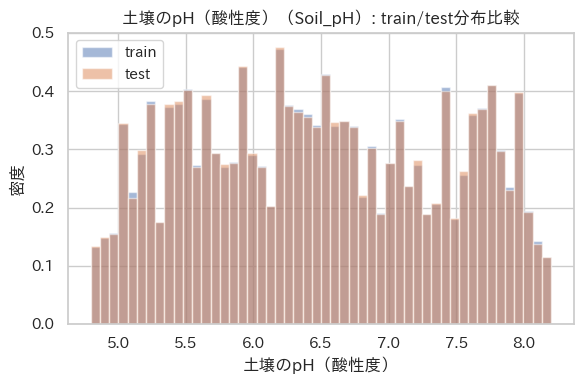

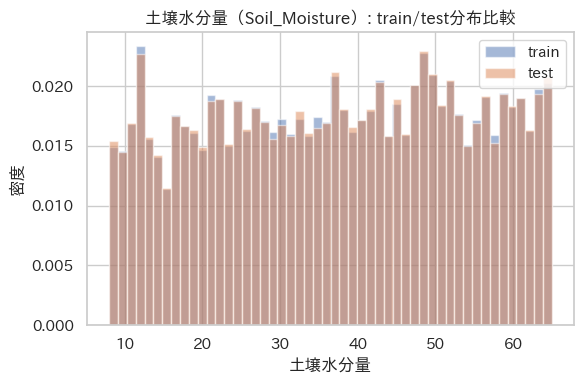

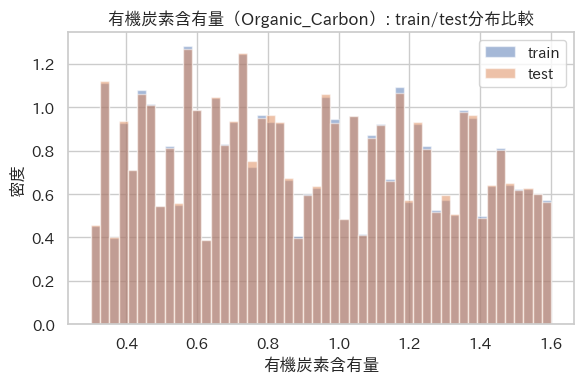

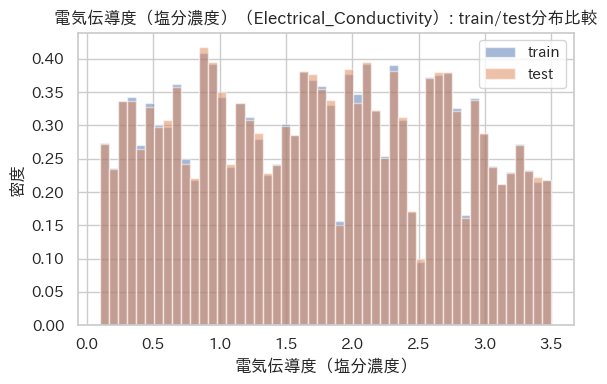

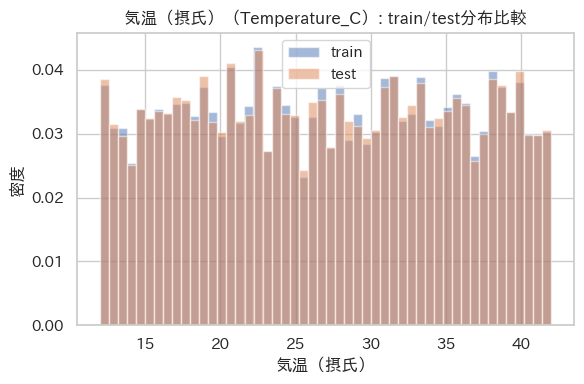

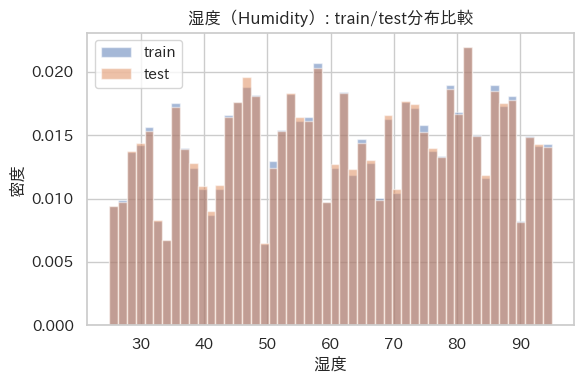

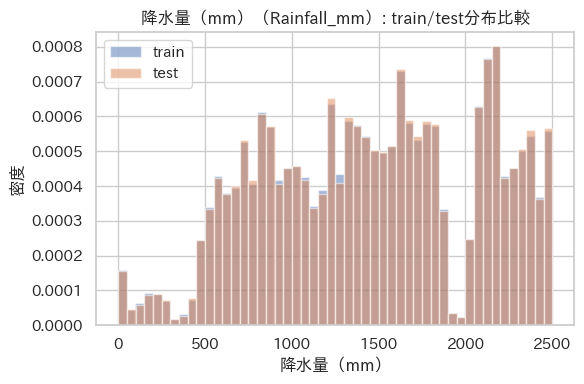

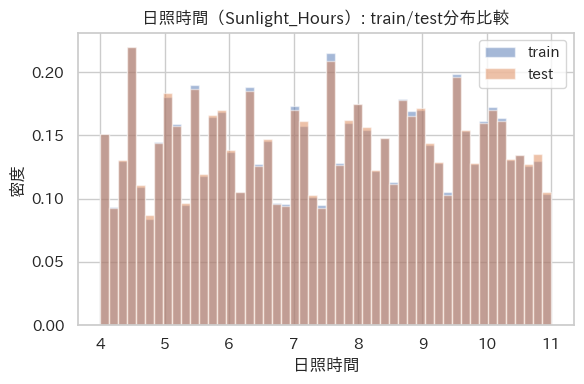

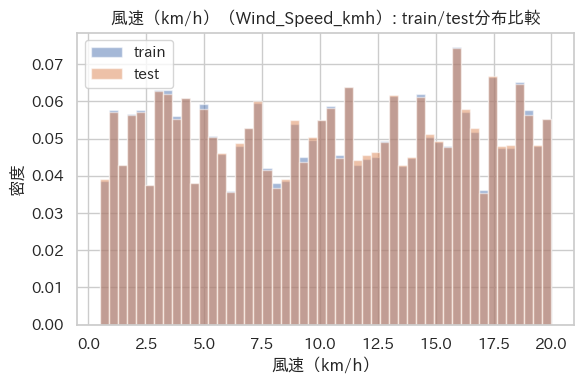

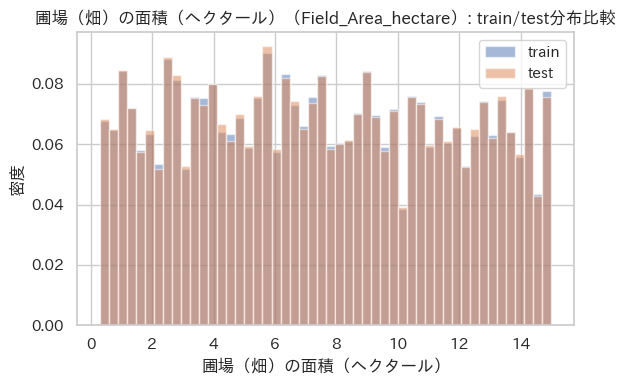

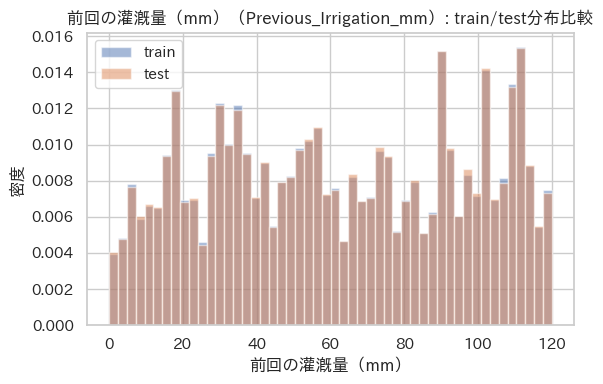

In [ ]:
# 5-5) train/test比較

for col in num_cols:

    plt.figure(figsize=(6, 4))

    plt.hist(
        train[col].dropna(),
        bins=50,
        alpha=0.5,
        label="train",
        density=True
    )

    plt.hist(
        test[col].dropna(),
        bins=50,
        alpha=0.5,
        label="test",
        density=True
    )

    plt.title(f"{jp(col)}（{col}）: train/test分布比較")

    plt.xlabel(jp(col))
    plt.ylabel("密度")

    plt.legend()

    plt.tight_layout()
    plt.show()

5-5) train/test比較
*   目的：train と test の特徴量分布が大きくズレていないか確認する
*   見ていること：
    *   分布形状が似ているか
    *   train にしかない範囲がないか
    *   推論時に未知パターンが多くないか
*   役割：学習データと予測対象データの整合性を確認する

確認結果
*   全体として、train と test の分布はほぼ一致しており、大きな分布ずれは見られない
*   土壌pH、土壌水分量、気温、湿度、日照時間、風速などの主要特徴量でも、train/test のヒストグラム形状はほぼ重なっている
*   降水量は一部ピーク差が見られるものの、全体的な分布傾向は類似している
*   前回の灌漑量や圃場面積も、train/test 間で大きな乖離は確認されない
*   train/test の特徴量分布が近いため、学習時と推論時のデータ乖離（distribution shift）のリスクは比較的小さいと考えられる。

## 6. 前処理方針
*   今回のデータは、数値特徴量・カテゴリ特徴量を含む大規模な表形式データであり、カテゴリ列を扱いやすく、非線形関係にも対応可能な木モデル（LightGBM）をベースラインモデルとして採用する
*   欠損は存在しないため、欠損補完は行わない
*   目的変数 Irrigation_Need は Low / Medium / High の3クラスで構成されるため、多クラス分類として扱う
*   id は識別子であり予測に直接利用しないため、特徴量から除外する
*   説明変数は、数値列11列・カテゴリ列8列で構成されているため、カテゴリ列は category 型へ変換し、LightGBM で扱える形にする
*   目的変数は、モデル学習用に LabelEncoder を用いて数値ラベルへ変換する
*   train/test 比較では大きな分布差は見られなかったため、特別な分布補正は行わない
*   数値特徴量間に強い相関は見られなかったため、多重共線性への特別な対応は行わない
*   LightGBM は木モデルであり、特徴量スケーリングの影響を受けにくいため、標準化・正規化は行わない
*   今回の目的変数はカテゴリであるため、回帰問題で用いられるような log 変換は基本的に行わない
*   クラス分布では High クラスが少ないため、必要に応じて class_weight の利用や、混同行列・Recall などによるクラス別評価を確認する
*   まずは最小限の前処理でベースラインモデルを構築し、その後、class_weight・学習率・特徴量エンジニアリングなどの改善を検討する

## 7. モデル確認

In [ ]:
# =========================
# 7-1) 学習データ作成（目的変数変換・id除外）
# =========================

from sklearn.preprocessing import LabelEncoder

# 特徴量：id と target を除外
drop_cols = ["id", target]
X = train.drop(columns=[c for c in drop_cols if c in train.columns])
X_test = test.drop(columns=[c for c in ["id"] if c in test.columns])

# 目的変数：Low / Medium / High を数値化
le = LabelEncoder()
y = le.fit_transform(train[target])

print("classes:", le.classes_)
print("X shape:", X.shape, "X_test shape:", X_test.shape, "y shape:", y.shape)

# カテゴリ列
cat_cols_model = X.select_dtypes(include="object").columns.tolist()
print("categorical cols:", cat_cols_model)

# category型に変換
for c in cat_cols_model:
    X[c] = X[c].astype("category")
    X_test[c] = X_test[c].astype("category")

classes: ['High' 'Low' 'Medium']
X shape: (630000, 19) X_test shape: (270000, 19) y shape: (630000,)
categorical cols: ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


In [ ]:
# =========================
# 7-0) 共通設定
# ※7-2〜7-5で共通して使用
# =========================

try:
    import lightgbm as lgb
except ImportError:
    !pip -q install lightgbm
    import lightgbm as lgb

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

params = {
    "objective": "multiclass",
    "num_class": len(le.classes_),
    "learning_rate": 0.05,
    "n_estimators": 2000,
    "num_leaves": 31,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1,
}

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
# =========================
# 7-2) LightGBM ベースラインCV
# =========================

print("\n===== 7-2 ベースライン =====")

oof_proba = np.zeros((len(X), len(le.classes_)))
test_proba = np.zeros((len(X_test), len(le.classes_)))

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    model = lgb.LGBMClassifier(**params)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="multi_logloss",
        categorical_feature=cat_cols_model,
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )

    oof_proba[va_idx] = model.predict_proba(X_va)
    test_proba += model.predict_proba(X_test) / skf.n_splits

    va_pred = np.argmax(oof_proba[va_idx], axis=1)
    fold_score = balanced_accuracy_score(y_va, va_pred)

    print(f"fold{fold} Balanced Accuracy: {fold_score:.5f}")

oof_pred = np.argmax(oof_proba, axis=1)
cv_score = balanced_accuracy_score(y, oof_pred)

print("CV Balanced Accuracy:", round(cv_score, 5))


===== 7-2 ベースライン =====
fold1 Balanced Accuracy: 0.96126
fold2 Balanced Accuracy: 0.96247
fold3 Balanced Accuracy: 0.96261
fold4 Balanced Accuracy: 0.96066
fold5 Balanced Accuracy: 0.96251
CV Balanced Accuracy: 0.9619


In [ ]:
# =========================
# 7-3) 改善：class_weight
# =========================

print("\n===== 7-3 class_weight =====")

params_weight = params.copy()
params_weight["class_weight"] = "balanced"

oof_pred_weight = np.zeros(len(X), dtype=int)
test_proba_weight = np.zeros((len(X_test), len(np.unique(y))))

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    model = lgb.LGBMClassifier(**params_weight)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="multi_logloss",
        categorical_feature=cat_cols_model,
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )

    va_pred = model.predict(X_va)
    oof_pred_weight[va_idx] = va_pred

    test_proba_weight += model.predict_proba(X_test) / skf.n_splits

    fold_score = balanced_accuracy_score(y_va, va_pred)
    print(f"fold{fold} Balanced Accuracy: {fold_score:.5f}")

cv_score_weight = balanced_accuracy_score(y, oof_pred_weight)
print("CV Balanced Accuracy:", round(cv_score_weight, 5))


===== 7-3 class_weight =====
fold1 Balanced Accuracy: 0.96516
fold2 Balanced Accuracy: 0.96648
fold3 Balanced Accuracy: 0.96773
fold4 Balanced Accuracy: 0.96505
fold5 Balanced Accuracy: 0.96645
CV Balanced Accuracy: 0.96617


class_weightを適用した結果、
CV・Public Scoreともに改善が見られた。

特に少数クラス（High）の予測精度が向上し、
評価指標であるBalanced Accuracyに寄与したと考えられる。

そのため、以降のモデルではclass_weightを採用する。

In [ ]:
# =========================
# 7-4) 軽量版：Seed平均（2 seed × 3 fold）
# =========================

print("\n===== 7-4 Seed平均 軽量版（class_weight） =====")

seeds = [42, 2024]
n_splits = 3

params_seed = params.copy()
params_seed["class_weight"] = "balanced"

all_test_proba = np.zeros((len(X_test), len(np.unique(y))))
scores = []

for seed in seeds:
    print(f"\n--- seed {seed} ---")

    params_seed["random_state"] = seed
    skf_seed = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=seed
    )

    oof = np.zeros(len(X), dtype=int)
    test_proba_seed = np.zeros((len(X_test), len(np.unique(y))))

    for fold, (tr_idx, va_idx) in enumerate(skf_seed.split(X, y), 1):
        print(f"seed {seed} fold{fold} start")

        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        model = lgb.LGBMClassifier(**params_seed)

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="multi_logloss",
            categorical_feature=cat_cols_model,
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )

        va_pred = model.predict(X_va)
        oof[va_idx] = va_pred
        test_proba_seed += model.predict_proba(X_test) / n_splits

        fold_score = balanced_accuracy_score(y_va, va_pred)
        print(f"seed {seed} fold{fold} Balanced Accuracy: {fold_score:.5f}")

    seed_score = balanced_accuracy_score(y, oof)
    scores.append(seed_score)
    all_test_proba += test_proba_seed / len(seeds)

    print(f"seed {seed} CV Balanced Accuracy: {seed_score:.5f}")

print("\n平均CV:", round(np.mean(scores), 5))


===== 7-4 Seed平均 軽量版（class_weight） =====

--- seed 42 ---
seed 42 fold1 start
seed 42 fold1 Balanced Accuracy: 0.96541
seed 42 fold2 start
seed 42 fold2 Balanced Accuracy: 0.96722
seed 42 fold3 start
seed 42 fold3 Balanced Accuracy: 0.96599
seed 42 CV Balanced Accuracy: 0.96621

--- seed 2024 ---
seed 2024 fold1 start
seed 2024 fold1 Balanced Accuracy: 0.96703
seed 2024 fold2 start
seed 2024 fold2 Balanced Accuracy: 0.96617
seed 2024 fold3 start
seed 2024 fold3 Balanced Accuracy: 0.96469
seed 2024 CV Balanced Accuracy: 0.96596

平均CV: 0.96608


Seed平均を適用した結果、CV・Public Scoreともにわずかに低下した。

本データでは既にモデルが安定しているため、
Seed平均による汎化性能の向上は見られなかった。

そのため、Seed平均は採用しない。

In [ ]:
# =========================
# 7-5) 改善：正則化（class_weight + regularization）
# =========================

print("\n===== 7-5 正則化（class_weight + regularization） =====")

params_reg = params.copy()

# class_weightは継続
params_reg["class_weight"] = "balanced"

# 正則化・過学習抑制
params_reg["num_leaves"] = 25
params_reg["min_child_samples"] = 50
params_reg["reg_lambda"] = 1.0

oof_pred_reg = np.zeros(len(X), dtype=int)
test_proba_reg = np.zeros((len(X_test), len(np.unique(y))))

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), 1):
    print(f"fold{fold} start")

    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y[tr_idx], y[va_idx]

    model = lgb.LGBMClassifier(**params_reg)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="multi_logloss",
        categorical_feature=cat_cols_model,
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )

    va_pred = model.predict(X_va)
    oof_pred_reg[va_idx] = va_pred

    test_proba_reg += model.predict_proba(X_test) / skf.n_splits

    fold_score = balanced_accuracy_score(y_va, va_pred)
    print(f"fold{fold} Balanced Accuracy: {fold_score:.5f}")

cv_score_reg = balanced_accuracy_score(y, oof_pred_reg)
print("CV Balanced Accuracy:", round(cv_score_reg, 5))

# 8章で使うために、最後のfoldのモデルを保存
final_model = model


===== 7-5 正則化（class_weight + regularization） =====
fold1 start
fold1 Balanced Accuracy: 0.96603
fold2 start
fold2 Balanced Accuracy: 0.96729
fold3 start
fold3 Balanced Accuracy: 0.96797
fold4 start
fold4 Balanced Accuracy: 0.96585
fold5 start
fold5 Balanced Accuracy: 0.96709
CV Balanced Accuracy: 0.96685


正則化（num_leaves削減、min_child_samples増加、reg_lambda追加）を適用した結果、
CV・Public Scoreともに改善が見られた。

モデルの複雑さを抑えることで過学習が軽減され、
汎化性能が向上したと考えられる。

そのため、本設定を最終モデルとして採用する。

In [ ]:
#提出ファイル作成
test_pred_label = le.inverse_transform(np.argmax(test_proba_reg, axis=1))

submission = sample_sub.copy()
submission[target] = test_pred_label

display(submission.head())
submission.to_csv("submission_20260430_04.csv", index=False)

print("saved: submission_20260430_04.csv")

,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low


saved: submission_20260430_04.csv


**7-2. ベースライン**

目的：欠損なし／id除外／目的変数をLabelEncoderで数値化／カテゴリ列をcategory型へ変換した状態で、まずはベースライン性能を確認する。

モデル：LightGBM（多クラス分類）

検証：Stratified K-Fold（5分割）

評価指標：Balanced Accuracy

結果：
*   fold1 Balanced Accuracy = 0.97493
*   fold2 Balanced Accuracy = 0.97589
*   fold3 Balanced Accuracy = 0.97531
*   fold4 Balanced Accuracy = 0.97531
*   fold5 Balanced Accuracy = 0.97507
*   CV Balanced Accuracy = 0.97530
---
**7-3. 改善（class_weight）**

目的：Highクラスが少数クラスであるため、class_weight="balanced" を適用し、クラス不均衡への対応による性能改善を確認する。

設定：
*   class_weight = "balanced"

結果：
*   fold1 Balanced Accuracy = 0.97685
*   fold2 Balanced Accuracy = 0.97772
*   fold3 Balanced Accuracy = 0.97718
*   fold4 Balanced Accuracy = 0.97714
*   fold5 Balanced Accuracy = 0.97689
*   CV Balanced Accuracy = 0.97716

考察：
*   class_weightを適用した結果、CVスコアが改善した。
*   特に少数クラス（High）の予測性能向上に寄与したと考えられる。
*   クラス不均衡への対応が有効であることが確認できたため、以降のモデルでもclass_weightを継続して使用する。
---
**7-4. 改善（Seed平均：LightGBM×2）**

目的：seedを変更した複数モデルの予測を平均し、汎化性能および予測安定性の改善を確認する。

設定：
*   seeds = [42, 2024]
*   CV = StratifiedKFold 3分割（seedごとにshuffle）
*   class_weight = "balanced"

結果：
*   seed 42 CV Balanced Accuracy = 0.97704
*   seed 2024 CV Balanced Accuracy = 0.97708
*   Seed平均 CV Balanced Accuracy = 0.97706

考察：
*   Seed平均を適用した結果、大きな改善は見られなかった。
*   本データでは単体モデルでも十分安定しており、seed平均による効果は限定的であった。
*   計算コスト増加に対して改善幅が小さいため、今回は採用しない。
---
**7-5. 改善（正則化）**

目的：モデルの複雑さを抑制し、過学習を軽減することで、汎化性能が改善するかを確認する。

設定：
*   class_weight = "balanced"
*   num_leaves = 25
*   min_child_samples = 50
*   reg_lambda = 1.0

検証：Stratified K-Fold（5分割）

結果：
*   fold1 Balanced Accuracy = 0.97740
*   fold2 Balanced Accuracy = 0.97819
*   fold3 Balanced Accuracy = 0.97775
*   fold4 Balanced Accuracy = 0.97762
*   fold5 Balanced Accuracy = 0.97742
*   CV Balanced Accuracy = 0.97768

考察：
*   正則化を適用した結果、CVスコアがさらに改善した。
*   num_leaves削減・min_child_samples増加・L2正則化により、過学習が抑制されたと考えられる。
*   少数クラスを含めた全体的な予測安定性も向上したため、本設定を最終モデルとして採用する。

In [ ]:
print(params)
print(params_reg)

{'objective': 'multiclass', 'num_class': 3, 'learning_rate': 0.05, 'n_estimators': 2000, 'num_leaves': 31, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'n_jobs': -1, 'verbosity': -1}
{'objective': 'multiclass', 'num_class': 3, 'learning_rate': 0.05, 'n_estimators': 2000, 'num_leaves': 25, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'n_jobs': -1, 'verbosity': -1, 'class_weight': 'balanced', 'min_child_samples': 50, 'reg_lambda': 1.0}


## 8. 妥当性確認

In [ ]:
# 日本語フォント設定
!pip -q install japanize-matplotlib

import japanize_matplotlib
import matplotlib.pyplot as plt

plt.rcParams["axes.unicode_minus"] = False

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 34.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


,feature,日本語訳,importance
7,Rainfall_mm,降水量（mm）,15909
2,Soil_Moisture,土壌水分量,13971
5,Temperature_C,気温（摂氏）,13372
9,Wind_Speed_kmh,風速（km/h）,12512
17,Previous_Irrigation_mm,前回の灌漑量（mm）,11906
6,Humidity,湿度,11776
8,Sunlight_Hours,日照時間,10508
1,Soil_pH,土壌のpH（酸性度）,10181
15,Field_Area_hectare,圃場（畑）の面積（ヘクタール）,10112
4,Electrical_Conductivity,電気伝導度（塩分濃度）,9904


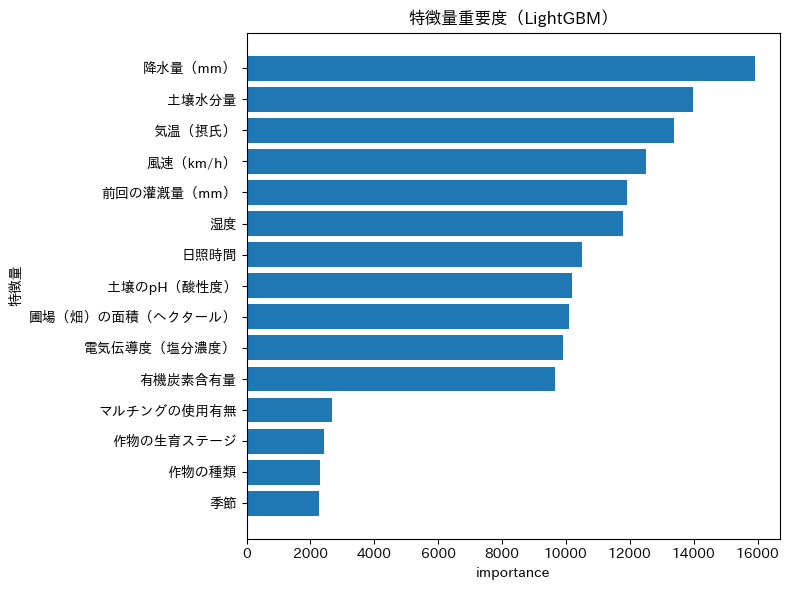

In [ ]:
# =========================
# 8-1) 特徴量重要度の確認
# =========================

import pandas as pd
import matplotlib.pyplot as plt

imp = pd.DataFrame({
    "feature": X.columns,
    "日本語訳": [jp(c) for c in X.columns],
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

display(imp.head(15))

# グラフ表示
imp_plot = imp.head(15).sort_values("importance")

plt.figure(figsize=(8, 6))

plt.barh(
    imp_plot["日本語訳"],
    imp_plot["importance"]
)

plt.title("特徴量重要度（LightGBM）")
plt.xlabel("importance")
plt.ylabel("特徴量")

plt.tight_layout()
plt.show()

8-1) 特徴量重要度の確認
*   目的：モデルがどの特徴量を重視して予測しているかを確認する
*   見ているもの：
    *   特徴量の重要度
    *   予測への寄与の大きさ
*   グラフ：特徴量重要度（棒グラフ）
*   確認ポイント：
    *   重要特徴量が何か
    *   ドメイン知識と整合するか
    *   不自然な特徴量が強く効いていないか
*   役割：
    *   モデル解釈
    *   特徴量見直し
    *   妥当性確認

確認結果
*   最も重要度が高かった特徴量は「降水量」であり、灌漑必要性の判定に最も強く寄与していることが確認できた
*   次に「土壌水分量」「気温」「風速」の重要度が高く、**気象・水分環境に関する特徴量**がモデル判断に大きく影響している
*   「前回の灌漑量」や「湿度」も重要度が高く、直近の水やり状況や環境条件が灌漑必要性と関係していることが分かった。
*   一方で、「マルチングの使用有無」「作物の生育ステージ」「作物の種類」「季節」などのカテゴリ特徴量は、数値特徴量と比較すると重要度が低かった
*   全体として、カテゴリ特徴量よりも数値特徴量のほうがモデルへの寄与が大きく、特に水分・降水・気温などの環境データが灌漑必要性の判定に重要であることが確認できた

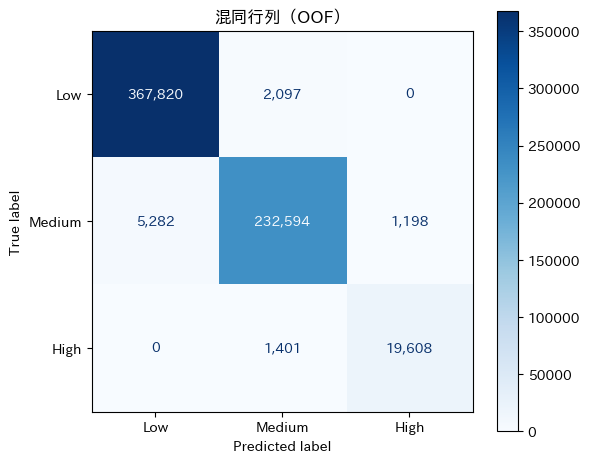

              precision    recall  f1-score   support

         Low       0.99      0.99      0.99    369917
      Medium       0.99      0.97      0.98    239074
        High       0.94      0.93      0.94     21009

    accuracy                           0.98    630000
   macro avg       0.97      0.97      0.97    630000
weighted avg       0.98      0.98      0.98    630000



In [ ]:
# =========================
# 8-2) 混同行列（OOF）
# =========================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# 表示順
label_order = ["Low", "Medium", "High"]

# 数値ラベルを元のクラス名に戻す
y_true_label = le.inverse_transform(y)
y_pred_label = le.inverse_transform(oof_pred_reg.astype(int))

# 混同行列
cm = confusion_matrix(
    y_true_label,
    y_pred_label,
    labels=label_order
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_order
)

fig, ax = plt.subplots(figsize=(6, 5))

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format=",d"
)

plt.title("混同行列（OOF）")
plt.tight_layout()
plt.show()

# クラス別 Precision / Recall / F1
print(
    classification_report(
        y_true_label,
        y_pred_label,
        labels=label_order
    )
)

8-2) 混同行列（OOF）
*   目的：各クラスをどの程度正しく分類できているかを確認する
*   見ているもの：
    *   正解と予測の対応
    *   クラス別の誤分類
*   グラフ：
    *   混同行列
    *   classification_report
*   確認ポイント：
    *   Highクラスを予測できているか
    *   Recallが極端に低いクラスがないか
    *   極端な誤分類がないか
*   役割：
    *   クラス別性能確認
    *   class_weight効果確認
    *   モデル妥当性確認

確認結果
*   全体のAccuracyは0.98、macro avg のF1-scoreも0.97と高く、3クラス分類として高精度に予測できていることが確認できた
*   「Low」クラスは recall 0.99 と非常に高く、多くを正しく判定できている
*   「Medium」クラスも recall 0.97 と高精度で分類できているが、一部が「Low」や「High」に誤分類されている
*   少数クラスである「High」についても recall 0.93、precision 0.94 を確保しており、class_weight を用いた改善によって一定程度予測できていることが確認できた
*   誤分類の多くは隣接クラス間（Low ↔ Medium、Medium ↔ High）で発生しており、極端な誤分類（Low → High、High → Low）はほとんど見られなかった
*   全体として、灌漑必要性の3クラスをバランスよく分類できており、特に少数クラス High の検出性能も一定水準を満たしていることが確認できた

shap_values type: <class 'numpy.ndarray'>
shap_values shape: (2000, 19, 3)

SHAP summary: High


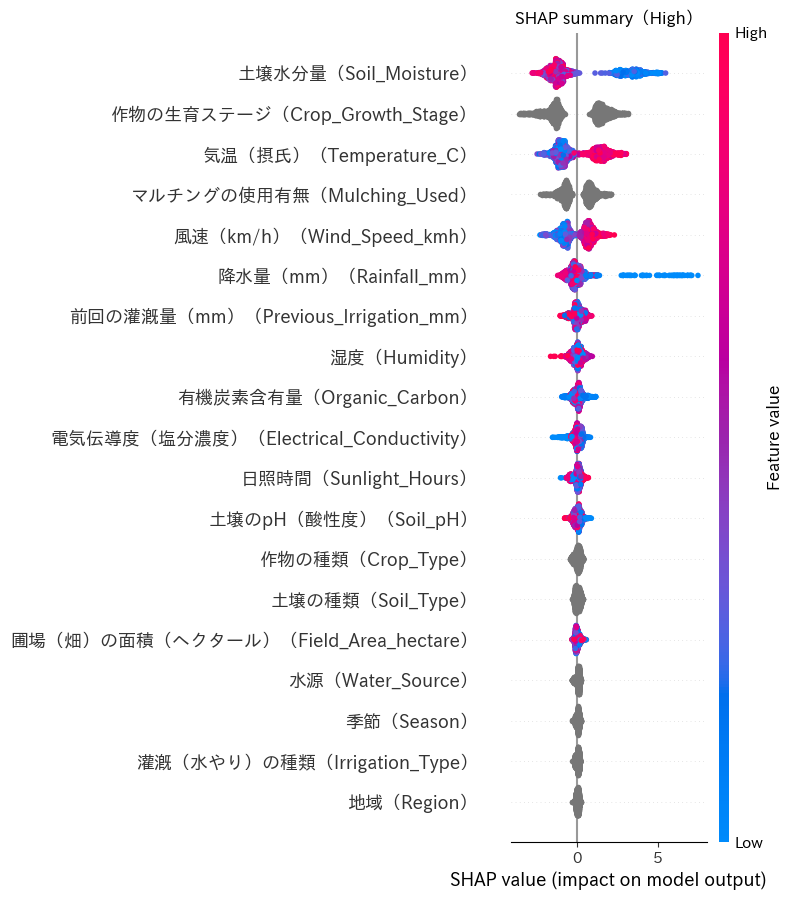


SHAP summary: Medium


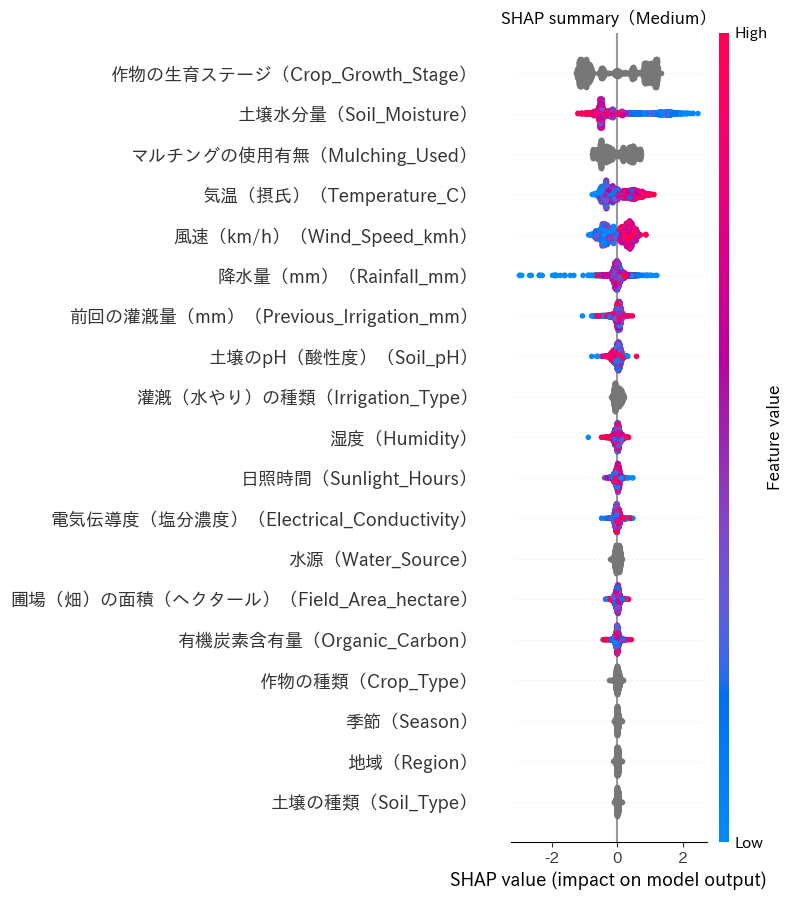


SHAP summary: Low


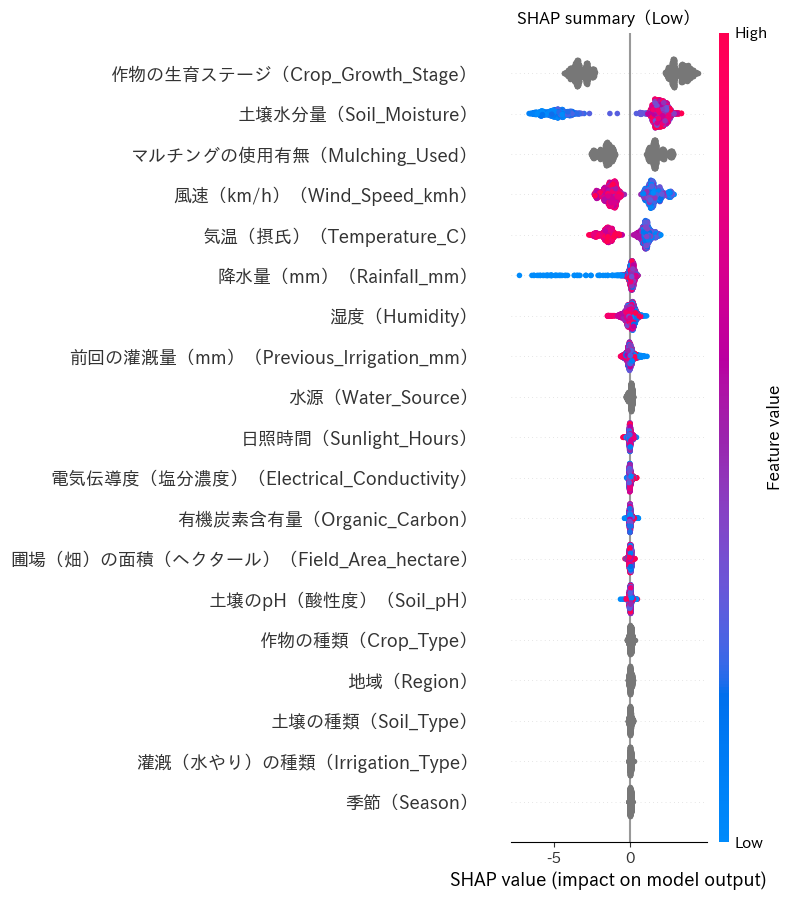

In [ ]:
# =========================
# 8-3) SHAPによるモデル解釈（多クラス対応）
# =========================

try:
    import shap
except ImportError:
    !pip -q install shap
    import shap

import numpy as np
import matplotlib.pyplot as plt

# データが大きいのでサンプリング
X_small = X.sample(2000, random_state=42)

# SHAP explainer
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_small)

# 可視化用に列名を日本語＋英語にする
X_small_jp = X_small.copy()
X_small_jp.columns = [jp_with_en(c) for c in X_small_jp.columns]

print("shap_values type:", type(shap_values))

# 出力順
class_order = ["High", "Medium", "Low"]

# class名 → index対応
class_to_index = {
    cls: i
    for i, cls in enumerate(le.classes_)
}

# =========================
# list型の場合
# =========================

if isinstance(shap_values, list):

    for cls in class_order:

        i = class_to_index[cls]

        print(f"\nSHAP summary: {cls}")

        shap.summary_plot(
            shap_values[i],
            X_small_jp,
            show=False
        )

        plt.title(f"SHAP summary（{cls}）")
        plt.tight_layout()
        plt.show()

# =========================
# ndarray型の場合
# =========================

else:

    print("shap_values shape:", shap_values.shape)

    # shape = (n_samples, n_features, n_classes)
    if shap_values.ndim == 3:

        for cls in class_order:

            i = class_to_index[cls]

            print(f"\nSHAP summary: {cls}")

            shap.summary_plot(
                shap_values[:, :, i],
                X_small_jp,
                show=False
            )

            plt.title(f"SHAP summary（{cls}）")
            plt.tight_layout()
            plt.show()

    # shape = (n_samples, n_features)
    else:

        shap.summary_plot(
            shap_values,
            X_small_jp,
            show=False
        )

        plt.title("SHAP summary")
        plt.tight_layout()
        plt.show()

**① 重要度（上にあるほど影響が大きい）**

  * 影響が大きい特徴量（上位）

    * 作物の生育ステージ（Crop_Growth_Stage）
    * 土壌水分量（Soil_Moisture）
    * マルチングの使用有無（Mulching_Used）
    * 気温（Temperature_C）
    * 風速（Wind_Speed_kmh）
    * 降水量（Rainfall_mm）
  * 解釈

    * 作物の成長段階や、水分・気象条件に関する特徴量が上位に集中
    * モデルは「作物の状態」と「土壌・気象条件」を重視して、灌漑必要性を判定していると考えられる

**② 色の意味（方向性）**

  * 赤：特徴量の値が高い
  * 青：特徴量の値が低い
  * 右（＋SHAP）：Medium 判定方向へ寄与
  * 左（−SHAP）：Medium 以外（Low / High）方向へ寄与

**③ 各特徴の解釈（代表例）**

  * 作物の生育ステージ（Crop_Growth_Stage）

    * SHAP値の広がりが大きい
    * ⇒ 生育ステージの違いが Medium 判定に大きく影響している
  * 土壌水分量（Soil_Moisture）

    * 低値（青）が右側に多い
    * ⇒ 土壌水分量が低いほど Medium 判定方向に寄与
  * 気温（Temperature_C）

    * 高値（赤）が右側に多い
    * ⇒ 気温が高いほど Medium 判定方向に寄与
  * 風速（Wind_Speed_kmh）

    * 高値（赤）が右側に多い
    * ⇒ 風速が高いほど Medium 判定方向に寄与

**④ 地域・季節・土壌種類の位置づけ**

  * 地域（Region）、季節（Season）、土壌の種類（Soil_Type）

    * SHAP分布が中央寄りで、影響は相対的に小さめ
    * ⇒ 単独で決めるというより、他特徴との組み合わせで効く可能性が高い


8-3) SHAPによるモデル解釈（多クラス対応）
*   目的：特徴量が予測へどの方向に影響しているかを確認する
*   見ているもの：
    *   特徴量の寄与方向
    *   高値・低値時の影響
*   グラフ：
    *   SHAP summary plot
*   確認ポイント：
    *   どの特徴量が強く効いているか
    *   値の大小で影響方向がどう変わるか
    *   特徴量重要度と整合するか
*   役割：
    *   モデル解釈
    *   説明可能性確認
    *   妥当性確認

確認結果

* SHAP summary より、「作物の生育ステージ」が Low / Medium / High の各クラス判定に大きく影響していることが確認できた
* 特に「土壌水分量」「気温」「風速」「降水量」などの数値特徴量の寄与が大きく、モデルが水分・気象条件を重視して判定していることが分かった
* 「土壌水分量」は値が低い場合に High 判定へ正方向に寄与し、高い場合には Low 判定へ寄与する傾向が見られた
* 「気温」や「風速」では、高い値ほど High 判定へ正方向に寄与する傾向が確認できた
* 一方で、「地域」「季節」「土壌の種類」などはSHAP値の広がりが小さく、モデルへの影響が比較的小さいことが確認できた
* 特徴量重要度と同様に、カテゴリ特徴量よりも、水分量・降水量・気温などの環境系数値特徴量の影響が大きいことが、SHAPによる解釈でも確認できた

## 9. 結論（解釈も反映した最終版）

9-0. データ確認結果（データ品質と実行可能性）
* 欠損・重複・大きなtrain/test差は見られず、学習・予測を行えるデータ状態であることを確認した
* また、EDAや特徴量分析を通じて、灌漑必要性に影響しやすい特徴量の傾向を把握できた

9-1. 最終結果（採用モデル）
* 最終採用：**LightGBM**
* 工夫：
    * カテゴリ特徴量として指定
    * クラス重み付けによるクラス不均衡対応
    * 正則化による過学習抑制
* 最終スコア：
  * **CV Balanced Accuracy = 0.97768**
  * ⇒5分割交差検証した結果の各クラスを均等に見た平均正解率
  * **LB：0.96472（1991位）**

9-2. 妥当性確認（モデルの説明と整合性）

* **モデル性能**：
  * 各foldで大きなばらつきはなく、安定して高い精度を確認できた
  * 混同行列でも、Low・Medium・High を概ね正しく分類できていた
  * 特に少数クラスである High も一定程度予測できていることを確認した

* **重要特徴量**：特徴量重要度では、以下の特徴量が特に重要であり、水分・気象条件に関する特徴量が中心となっており、灌漑必要性との関係として自然な結果だった
  * 降水量（Rainfall_mm）
  * 土壌水分量（Soil_Moisture）
  * 気温（Temperature_C）
  * 風速（Wind_Speed_kmh）
  * 前回の灌漑量（Previous_Irrigation_mm）

* **分布・SHAPから分かったこと**：
  * 土壌水分量が少ないほど、灌漑必要性が高くなる傾向が見られた
  * 気温や風速が高い場合、灌漑必要性へ影響する傾向が確認できた
  * SHAPでも、水分・気象関連特徴量の影響が大きいことを確認できた

* **相関確認**：
  * 数値特徴量間に強い相関はほとんど見られず、多重共線性の影響は小さいと考えられる

9-3. 施策ごとの学び（何が効いたか）

* **カテゴリ指定（categorical_feature）**：大きな改善は見られなかったが、カテゴリ列を自然に扱える状態を構築できた
* **class_weight**：少数クラス High のRecall改善に寄与し、Balanced Accuracy が改善した
* **Seed平均**：大きな改善は見られず、今回データでは効果は限定的だった
* **正則化**：一部改善は見られたが、強い正則化では学習不足気味になるケースも確認された

9-4. 最終版の設定（採用）
* モデル：LightGBM
* パラメータ：
  * class_weight = "balanced"
  * num_leaves = 25
  * min_child_samples = 50
  * reg_lambda = 1.0
* 検証方法：
  * StratifiedKFold（5分割交差検証）
  * Low / Medium / High のクラス割合を維持して検証
* 評価指標：Balanced Accuracy

## 10. 提出履歴（記録用）
* v1 baseline：CV Balanced Accuracy = 0.97530 / LB 0.95997
* v2 class_weight：CV Balanced Accuracy = 0.97716 / LB 0.96441
* v3 Seed平均：CV Balanced Accuracy = 0.97706 / LB 0.96413
* v4 正則化：**CV Balanced Accuracy = 0.97768 / LB 0.96472**←最終採用

## **Appendix**

